# 06 — Modelling: the ladder, and the reject option

This notebook answers one question: **does anything in the leakage-safe feature table
predict who buys again within 30 days of their first order, well enough to be worth
shipping?**

The analysis *is* the nested ladder. M0 → M1 → M2 → M3 → M4 with a likelihood-ratio test
between each consecutive pair is the formal test of which block carries signal, and it is
reported in full before any tree model appears. LightGBM enters afterwards, with exactly
one job: to test whether nonlinearity buys anything over the logistic M4. It does not get
to be the headline by default.

**The reject option is live.** Every signal measured so far in this project is weak —
Cramér's V of 0.09–0.13 on repeat purchase (02 §5), a univariate AUC ceiling of 0.6097
across all 81 eligible features (05 §14B), a cadence base AUC of 0.5521 (05 §7). 05's
binding rule is explicit: *a fitted model that does not clearly beat 0.6097 is not worth
shipping over a one-feature rule on `pre_n_products`.* If the model does not beat the
naive baselines, the finding is that the signal is not there, and that is the deliverable.
No feature was added, no hyperparameter re-tuned, and no split re-cut to rescue a number.

**The target is `repeat_purchase_30d` and it is not churn.** Under the certified 42.2-day
rule no user can be churned before day 42.2, so a 30-day horizon cannot carry a churn
label. The word "churn" appears here only when describing 03's rule or 04's §9B
recommendation.

---

### What this notebook concludes, stated up front

1. **M3 (pre-`t0` browsing) carries the signal, in every ordering and at every horizon.**
   Entering first it buys 1,598 χ² on 26 df; entering third it still buys 927. M1 buys
   1,119 entering first and 497 entering last. M4 (cadence) buys ~122 χ² on 13 df whether
   it enters second or last — its position does not matter because it has almost nothing
   to add.
2. **M4's standalone strength is M3 volume wearing a different name.**
   `cad_n_hist_gaps` is exactly `pre_n_sessions − 2` on all 42,190 rows where it is
   defined. That is not a correlation; it is an identity.
3. **The model is *mostly* a one-dimensional activity-intensity score, but not entirely.**
   The first principal component of eleven M3 volume features (68.5% of their variance)
   recovers 80% of everything the 62-feature logistic buys over the base rate. A single
   raw feature recovers 74%. The remaining margin is statistically real and small.
4. **LightGBM does not beat the logistic on the primary metric.** ΔAP = +0.0039,
   95% CI [−0.0017, +0.0101]. The logistic M4 ships.
5. **The shipped model does beat the naive baselines**, so this is not a rejection:
   ΔAP vs the one-feature rule = +0.0167 [+0.0099, +0.0237]. It is a weak model that is
   honestly better than the alternatives, operating at a decile-1 lift of 1.88×.
6. **04 §9B is settled, negatively.** Re-anchored on the second order, where purchase
   cadence actually exists, a personalised cadence-multiple scores Youden's J = 25.12
   against the global 42.2-day rule's 24.56 — ΔJ = +0.55, 95% CI [−0.93, +1.94]. It does
   not beat a global threshold. A *tuned* global threshold (38.0d, J = 25.48) beats both.

In [1]:
import os, sys, json, time, warnings, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from scipy.linalg import qr
from scipy.optimize import brentq
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (average_precision_score, roc_auc_score, brier_score_loss,
                             confusion_matrix, precision_recall_curve)

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

from src.plotting import frame, add_title, add_takeaway, save, show_df, thousands
from src.data import connect, materialize, create_orders_view, round_sig

SEED = 42
np.random.seed(SEED)
TABLES_DIR    = os.path.join("outputs", "tables")
FIG_DIR       = os.path.join("outputs", "figures")
PROCESSED_DIR = os.path.join("data", "processed")
for d in (TABLES_DIR, FIG_DIR, PROCESSED_DIR):
    os.makedirs(d, exist_ok=True)

with open(os.path.join("outputs", "handoff_params.json")) as f:
    handoff = json.load(f)

FEAT       = handoff["features"]
CHURN      = handoff["churn_definition"]
UNI        = FEAT["univariate_ceiling"]
K_CERT     = float(CHURN["certified_threshold_days"])
UNI_CEIL   = float(UNI["max_auc"])
UNI_FEAT   = UNI["max_auc_feature"]
DATA_END_H = pd.Timestamp(handoff["data_date_range"]["max"])
PRIMARY_H  = int(handoff["retention_horizon"]["primary_days"])
HORIZONS   = [30, 60, 90]

print("INHERITED FROM handoff_params.json -- NOT RE-DERIVED")
print("=" * 98)
print(f"  feature table       : {FEAT['file']}  ({FEAT['n_rows']:,} rows x {FEAT['n_columns']} cols, "
      f"{FEAT['n_model_eligible']} model-eligible)")
print(f"  anchor              : {FEAT['anchor']}")
print(f"  primary target      : repeat_purchase_{PRIMARY_H}d   n={FEAT['eligible_n']['d30']:,}  "
      f"positive rate {FEAT['positive_rate_pct']['d30']}%")
print(f"  univariate ceiling  : {UNI_CEIL:.4f} ROC-AUC ({UNI_FEAT}) -- the bar a fitted model must clear")
print(f"  churn threshold     : {K_CERT}d -- referenced ONLY in Section 10 (04 s9B), never as this target")
print()
print("THE SEVEN BINDING RULES FROM 05 (features.binding_rules_for_06), verbatim:")
print("=" * 98)
for i, r in enumerate(FEAT["binding_rules_for_06"], 1):
    print(f"  {i}. {r}")

INHERITED FROM handoff_params.json -- NOT RE-DERIVED
  feature table       : data/processed/features.parquet  (109,732 rows x 96 cols, 81 model-eligible)
  anchor              : t0 = each user's first order timestamp, certified reconstruction rule
  primary target      : repeat_purchase_30d   n=91,334  positive rate 13.73%
  univariate ceiling  : 0.6097 ROC-AUC (pre_n_products) -- the bar a fitted model must clear
  churn threshold     : 42.2d -- referenced ONLY in Section 10 (04 s9B), never as this target

THE SEVEN BINDING RULES FROM 05 (features.binding_rules_for_06), verbatim:
  1. Subset on eligible_{h}d. Never zero-fill a censored user -- an unobserved window is not a negative.
  2. Split CHRONOLOGICALLY on first_ts, never randomly (CLAUDE.md principle 6).
  3. Use only model_eligible == True columns. t0_calendar_day, trailing_days, is_bulk_buyer_fullhistory and pre_segment are in the file for diagnostics and must not be fitted on.
  4. Encode fo_primary_brand / fo_primary_catego

In [2]:
# ---------------------------------------------------------------------------------------
# ENVIRONMENT NOTE, recorded because it is part of reproducing this notebook.
# LightGBM's macOS wheel links libomp by @rpath and searches Homebrew/MacPorts prefixes
# only. Neither exists on this machine. The OpenMP runtime scikit-learn already vendors
# was copied into lightgbm/lib/ and an @loader_path rpath added, then the dylib re-signed.
# This changes no numerical behaviour; it only makes `import lightgbm` resolve.
# ---------------------------------------------------------------------------------------
import lightgbm as lgb
print(f"lightgbm {lgb.__version__}   statsmodels {sm.__version__}   "
      f"numpy {np.__version__}   pandas {pd.__version__}")

# The three determinism guards from 05 are binding on this notebook. Sections 1-9 and 11
# read the PERSISTED feature table and never touch DuckDB, so guard 1 (threads=1 on the
# fetch) and guard 2 (round_sig) are already baked into features.parquet. Guard 3 -- a
# canonical row order -- is NOT, because parquet preserves whatever order 05 wrote, and
# every split, fold and bootstrap here indexes by position. It is re-imposed explicitly.
# Section 10 goes back to DuckDB and reproduces all three via fetch_block().
BUILD_THREADS, FETCH_THREADS = 6, 1

def fetch_block(con, sql):
    """05's three determinism guards, reproduced verbatim (features.determinism is
       binding_on_06_and_later: 'call fetch_block() or reproduce all three guards')."""
    con.execute(f"SET threads={FETCH_THREADS}")
    try:
        df = con.execute(sql).fetchdf()
    finally:
        con.execute(f"SET threads={BUILD_THREADS}")
    floats = [c for c in df.columns if df[c].dtype.kind == "f"]
    return round_sig(df, floats, sig=6).sort_values("user_id").reset_index(drop=True)

def frame_hash(df):
    """Content fingerprint used by the self-verification section."""
    return hashlib.sha256(pd.util.hash_pandas_object(df, index=False).values.tobytes()).hexdigest()[:16]

lightgbm 4.7.0   statsmodels 0.15.0   numpy 2.5.3   pandas 2.3.3


## 1. Population, eligibility, and the chronological split

Nothing here is re-derived. `eligible_30d` is 05's flag, built on exact elapsed seconds
against `DATA_END`; a censored user is excluded, never zero-filled, because an unobserved
window is not a negative.

The split is chronological on `first_ts` — a random split would let a model trained on
January users predict October users, which is not the decision anyone faces. 70% of users
by `t0` order form the training fold; the most recent 30% form the test fold. For
LightGBM's early stopping a validation fold is carved chronologically from *within* train
(its last 20%), so the test fold is never seen during fitting or model selection.

**One consequence of splitting on time, stated before any metric is reported:** the
positive rate is not stationary. It falls from 17.2% in the October cohort to 10.1% in
December. Train sits at 14.62% and test at 11.65% — a 3.0pp drop that no model can know
about. Ranking metrics (AP, ROC-AUC) are unaffected; *level* calibration is, and Section 8
deals with it honestly rather than by recalibrating on the test labels.

In [3]:
t_start = time.time()
features = pd.read_parquet(os.path.join(PROCESSED_DIR, "features.parquet"))
fdict    = pd.read_csv(os.path.join(TABLES_DIR, "nb05_feature_dictionary.csv"))

ELIGIBLE_COLS = fdict.loc[fdict.model_eligible, "feature"].tolist()
BLOCK_OF      = dict(zip(fdict.feature, fdict.block))
CAT_COLS      = ["fo_primary_brand", "fo_primary_category", "fs_entry_event_type"]
BLOCK_ORDER_A = ["M1 first order", "M2 first-order session", "M3 pre-t0 browsing", "M4 cadence"]
BLOCK_ORDER_B = ["M3 pre-t0 browsing", "M4 cadence", "M2 first-order session", "M1 first order"]

# BINDING RULE 3 -- only model_eligible == True columns may be fitted on.
FORBIDDEN = fdict.loc[~fdict.model_eligible, "feature"].tolist()
assert len(ELIGIBLE_COLS) == FEAT["n_model_eligible"] == 81
assert set(ELIGIBLE_COLS).isdisjoint(FORBIDDEN)

def population(h):
    """BINDING RULE 1 -- subset on eligible_{h}d. Canonical row order re-imposed here."""
    d = features[features[f"eligible_{h}d"]].copy()
    return d.sort_values(["first_ts", "user_id"]).reset_index(drop=True)

def chrono_split(d, frac=0.70):
    """BINDING RULE 2 -- split chronologically on first_ts, never randomly."""
    ts = d.first_ts.iloc[int(round(frac * len(d)))]
    return d[d.first_ts < ts].copy(), d[d.first_ts >= ts].copy(), ts

D30 = population(30)
TARGET = f"repeat_purchase_{PRIMARY_H}d"
tr30, te30, SPLIT_TS = chrono_split(D30)
VAL_TS = tr30.first_ts.iloc[int(round(0.80 * len(tr30)))]
trs30, va30 = tr30[tr30.first_ts < VAL_TS].copy(), tr30[tr30.first_ts >= VAL_TS].copy()

rows = []
for nm, d in [("D30 eligible (all)", D30), ("  train", tr30), ("    train-sub (LGBM fit)", trs30),
              ("    validation (early stop)", va30), ("  test (held out)", te30)]:
    rows.append(dict(fold=nm, n=len(d), share_pct=100 * len(d) / len(D30),
                     t0_from=str(d.first_ts.min())[:16], t0_to=str(d.first_ts.max())[:16],
                     positive_rate_pct=100 * d[TARGET].mean()))
split_tbl = show_df(pd.DataFrame(rows).round(3), "nb06_split_summary")

print()
print(f"chronological cut at t0 = {SPLIT_TS}   (validation cut at {VAL_TS})")
print(f"  max train t0 {tr30.first_ts.max()}  <  min test t0 {te30.first_ts.min()}   -> disjoint in time")
print(f"  users in both folds: {len(set(tr30.user_id) & set(te30.user_id))}")
print(f"  eligible N {len(D30):,} vs 05's {FEAT['eligible_n']['d30']:,}   "
      f"positive rate {100*D30[TARGET].mean():.2f}% vs 05's {FEAT['positive_rate_pct']['d30']}%")

                          fold      n  share_pct           t0_from             t0_to  positive_rate_pct
0           D30 eligible (all)  91334      100.0  2019-10-01 00:06  2020-01-30 23:55             13.730
1                        train  63934       70.0  2019-10-01 00:06  2019-12-18 06:03             14.620
2         train-sub (LGBM fit)  51147       56.0  2019-10-01 00:06  2019-11-29 23:06             15.688
3      validation (early stop)  12787       14.0  2019-11-29 23:07  2019-12-18 06:03             10.346
4              test (held out)  27400       30.0  2019-12-18 06:04  2020-01-30 23:55             11.653

chronological cut at t0 = 2019-12-18 06:04:25   (validation cut at 2019-11-29 23:07:59)
  max train t0 2019-12-18 06:03:48  <  min test t0 2019-12-18 06:04:25   -> disjoint in time
  users in both folds: 0
  eligible N 91,334 vs 05's 91,334   positive rate 13.73% vs 05's 13.73%


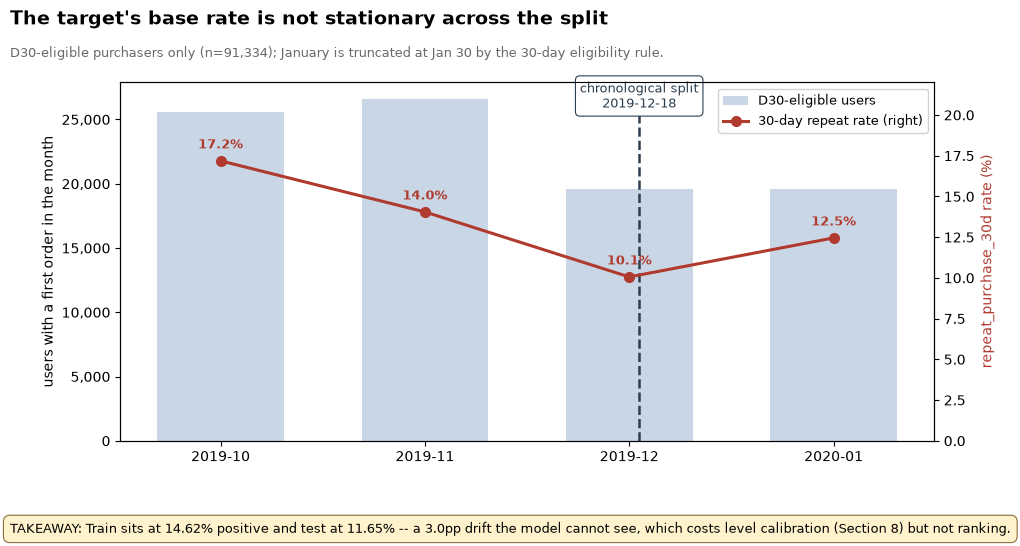

In [4]:
mon = D30.groupby(D30.first_ts.dt.to_period("M")).agg(n=("user_id", "size"), pos=(TARGET, "mean"))
mon.index = mon.index.astype(str)

fig, ax = frame(figsize=(10.5, 5.6))
ax.bar(range(len(mon)), mon.n, color="#C9D6E5", width=0.62, label="D30-eligible users")
ax.set_ylabel("users with a first order in the month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_xticks(range(len(mon))); ax.set_xticklabels(mon.index)
ax2 = ax.twinx()
ax2.plot(range(len(mon)), 100 * mon.pos, "o-", color="#B03A2E", lw=2.2, ms=7,
         label="30-day repeat rate (right)")
for i, v in enumerate(100 * mon.pos):
    ax2.annotate(f"{v:.1f}%", (i, v), textcoords="offset points", xytext=(0, 9),
                 ha="center", fontsize=9, color="#B03A2E", fontweight="bold")
ax2.set_ylabel("repeat_purchase_30d rate (%)", color="#B03A2E")
ax2.set_ylim(0, 22)
cut_x = (SPLIT_TS.to_period("M") - D30.first_ts.min().to_period("M")).n + \
        (SPLIT_TS.day - 1) / SPLIT_TS.days_in_month - 0.5
ax.axvline(cut_x, color="#2C3E50", ls="--", lw=1.8)
ax.annotate("chronological split\n" + str(SPLIT_TS)[:10], (cut_x, ax.get_ylim()[1] * 0.93),
            ha="center", fontsize=9, color="#2C3E50",
            bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#2C3E50", lw=0.8))
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=9, framealpha=0.9)
add_title(fig, "The target's base rate is not stationary across the split",
          f"D30-eligible purchasers only (n={len(D30):,}); January is truncated at Jan 30 by the 30-day eligibility rule.")
add_takeaway(fig, f"Train sits at {100*tr30[TARGET].mean():.2f}% positive and test at {100*te30[TARGET].mean():.2f}% "
                  f"-- a {100*(tr30[TARGET].mean()-te30[TARGET].mean()):.1f}pp drift the model cannot see, which "
                  f"costs level calibration (Section 8) but not ranking.")
save(fig, "nb06_base_rate_drift"); plt.show()

## 2. Three encoding decisions, made explicitly

Everything in this section is a rule, stated once and applied everywhere, because each one
is a place where a leakage-safe table can be made leaky again inside the model.

**2A — Categoricals are encoded inside the training fold.** `fo_primary_brand` (1,143
levels) and `fo_primary_category` (472 levels) are high-cardinality; encoding them on the
full table is an F3 violation (binding rule 4). They are out-of-fold target-encoded with
5-fold stratified splits *within train only*, smoothed toward the train prior with
m = 50; the test fold is mapped with the full-train mapping and unseen levels fall back to
the train prior. `fs_entry_event_type` is low-cardinality and gets the same treatment for
consistency.

**2B — Nulls get a sentinel and an indicator. This is not imputation.** Binding rule 6
forbids imputing, and 05 built a named indicator for every missing block. A sentinel of 0
plus an indicator is *not* a guess at the missing value: with one indicator per distinct
missingness pattern, the indicator absorbs the whole contribution of the sentinel rows, so
the slope is identified off the observed rows and the sentinel is never interpretable as a
value. 05's four named indicators do not cover every pattern — `fs_max_price_viewed` is
25.6% missing where the rest of M2 is 10.6%, and M4 holds four separate patterns — so an
indicator is built for **each distinct train-fold missingness pattern** and assigned to the
earliest block that produces it, which keeps the ladder's design matrices strictly nested.

**2C — One feature per flagged collinear pair, chosen on the train fold only.** 05 flagged
23 pairs at |ρ| ≥ 0.90 and 31 features at VIF ≥ 10 but deliberately dropped nothing. The
selection rule here: build the graph of flagged pairs, take its connected components, and
keep the member with the **highest train-fold univariate AUC**, breaking ties on lower
train missingness and then alphabetically. The ranking is computed on train alone, so no
test row influences which features exist. LightGBM keeps all 81 — it does not care.

In [5]:
def target_encode(tr_s, te_s, y_tr, prior, m=50, n_splits=5, seed=SEED):
    """RULE 2A. Out-of-fold target encoding fitted INSIDE the training fold (binding rule 4).
       Returns (train OOF encoding, test encoding under the full-train mapping)."""
    tr_s = tr_s.astype("object").where(tr_s.notna(), "__NULL__")
    te_s = te_s.astype("object").where(te_s.notna(), "__NULL__")
    y = np.asarray(y_tr, dtype=float)
    oof = np.full(len(tr_s), np.nan)
    for i_fit, i_out in StratifiedKFold(n_splits, shuffle=True, random_state=seed).split(tr_s, y):
        g = pd.DataFrame({"k": tr_s.to_numpy()[i_fit], "y": y[i_fit]}).groupby("k").y.agg(["sum", "count"])
        mp = (g["sum"] + m * prior) / (g["count"] + m)
        oof[i_out] = pd.Series(tr_s.to_numpy()[i_out]).map(mp).fillna(prior).to_numpy()
    g = pd.DataFrame({"k": tr_s.to_numpy(), "y": y}).groupby("k").y.agg(["sum", "count"])
    mp = (g["sum"] + m * prior) / (g["count"] + m)
    return oof, pd.Series(te_s.to_numpy()).map(mp).fillna(prior).to_numpy()

def make_matrix(tr, te, feats, y_tr, seed=SEED):
    """Numeric columns as-is; categoricals target-encoded in-fold. NaNs left as NaN here."""
    Xtr = pd.DataFrame(index=tr.index); Xte = pd.DataFrame(index=te.index)
    prior = float(np.mean(y_tr))
    for c in feats:
        if c in CAT_COLS:
            a, b = target_encode(tr[c], te[c], y_tr, prior, seed=seed)
            Xtr[c + "__te"] = a; Xte[c + "__te"] = b
        else:
            Xtr[c] = pd.to_numeric(tr[c], errors="coerce").astype(float)
            Xte[c] = pd.to_numeric(te[c], errors="coerce").astype(float)
    return Xtr, Xte

def indicator_plan(Xtr, blocks, order):
    """RULE 2B. One indicator per DISTINCT train missingness pattern, owned by the earliest
       block in `order` that produces it -- so ladder design matrices stay strictly nested."""
    plan, seen = {}, {}
    for b in order:
        for c in blocks[b]:
            col = c + "__te" if c in CAT_COLS else c
            if col not in Xtr.columns:
                continue
            msk = Xtr[col].isna()
            if not msk.any():
                continue
            key = msk.to_numpy().tobytes()
            if key in seen:
                continue
            seen[key] = col
            plan[f"miss__{col}"] = (b, msk.to_numpy())
    return plan

def attach_indicators(Xtr, Xte, plan):
    for nm, (_, msk) in plan.items():
        src = nm[len("miss__"):]
        Xtr[nm] = msk.astype(float)
        Xte[nm] = Xte[src].isna().astype(float)
    return Xtr, Xte

def full_rank(Z, tol=1e-9):
    """Drop constants, exact duplicates, then any remaining linear dependency by pivoted QR.
       The SPAN is preserved, so a ladder step still contains the previous step's column
       space -- which is what the LR test requires. df is the RANK difference."""
    keep, seen = [], {}
    for c in Z.columns:
        v = Z[c].to_numpy(float)
        if np.nanstd(v) == 0:
            continue
        k = np.round(v, 12).tobytes()
        if k in seen:
            continue
        seen[k] = c; keep.append(c)
    Z = Z[keep]
    A = Z.to_numpy(float); sd = A.std(0); sd[sd == 0] = 1.0
    A = np.c_[np.ones(len(A)), (A - A.mean(0)) / sd]
    _, R, P = qr(A, mode="economic", pivoting=True)
    r = np.abs(np.diag(R)); rank = int((r > tol * r[0]).sum())
    return Z.iloc[:, [i - 1 for i in sorted(P[:rank]) if i > 0]]

def fit_logit(Xtr, y):
    """Standardised MLE logistic. Standardisation is a reparameterisation -- it changes no
       log-likelihood and therefore no LR test -- but it is what makes Newton converge here."""
    Z = full_rank(Xtr.fillna(0.0))
    mu, sd = Z.mean(), Z.std(ddof=0).replace(0, 1.0)
    Zs = sm.add_constant((Z - mu) / sd, has_constant="add")
    res = sm.Logit(y, Zs).fit(disp=0, method="newton", maxiter=200)
    if not res.mle_retvals.get("converged", False):
        res = sm.Logit(y, Zs).fit(disp=0, method="bfgs", maxiter=3000)
    return res, Z.columns.tolist(), mu, sd

def predict_logit(res, used, mu, sd, X):
    Z = X[used].fillna(0.0)
    return res.predict(sm.add_constant((Z - mu[used]) / sd[used], has_constant="add")).to_numpy()

def uni_auc(x, y):
    x = np.asarray(x, dtype=float); m = np.isfinite(x)
    if m.sum() < 50 or len(np.unique(x[m])) < 2:
        return np.nan
    a = roc_auc_score(np.asarray(y)[m], x[m])
    return max(a, 1 - a)
print("encoding rules defined")

encoding rules defined


In [6]:
# ----- RULE 2C: collinearity pruning, decided on the TRAIN fold only ---------------------
y_tr30 = tr30[TARGET].astype(int).to_numpy()
y_te30 = te30[TARGET].astype(int).to_numpy()

train_uni = {}
for c in ELIGIBLE_COLS:
    if c in CAT_COLS:
        a, _ = target_encode(tr30[c], te30[c], y_tr30, y_tr30.mean())
        train_uni[c] = uni_auc(a, y_tr30)
    else:
        train_uni[c] = uni_auc(pd.to_numeric(tr30[c], errors="coerce"), y_tr30)

pairs_tbl = pd.read_csv(os.path.join(TABLES_DIR, "nb05_collinear_pairs.csv"))

def components(pairs):
    parent = {}
    def find(x):
        parent.setdefault(x, x)
        while parent[x] != x:
            parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for a, b in pairs:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb
    comp = {}
    for f_ in sorted({x for p in pairs for x in p}):
        comp.setdefault(find(f_), []).append(f_)
    return comp

def pick(members):
    """highest train univariate AUC -> lower train missingness -> alphabetical."""
    return sorted(sorted(members),
                  key=lambda c: (-(train_uni.get(c) or 0.0), float(tr30[c].isna().mean()), c))

GLOBAL_COMP = components([(r.a, r.b) for r in pairs_tbl.itertuples()])
keep_flag, prune_rows = {}, []
for _, members in GLOBAL_COMP.items():
    ranked = pick(members)
    for m_ in members:
        keep_flag[m_] = (m_ == ranked[0])
    prune_rows.append(dict(component_size=len(members), kept=ranked[0],
                           kept_block=BLOCK_OF[ranked[0]], kept_train_auc=train_uni[ranked[0]],
                           dropped=", ".join(f"{m_} ({train_uni[m_]:.4f}, {BLOCK_OF[m_].split()[0]})"
                                             for m_ in ranked[1:])))
LOGIT_FEATS = [c for c in ELIGIBLE_COLS if keep_flag.get(c, True)]
prune_tbl = show_df(pd.DataFrame(prune_rows).sort_values("component_size", ascending=False).round(4),
                    "nb06_collinearity_pruning", max_rows=20)

BLOCKS = {}
for c in LOGIT_FEATS:
    BLOCKS.setdefault(BLOCK_OF[c], []).append(c)
print()
print(f"23 flagged pairs collapse to {len(GLOBAL_COMP)} components; "
      f"{81 - len(LOGIT_FEATS)} features dropped, {len(LOGIT_FEATS)} kept for the logistic ladder.")
for b in BLOCK_ORDER_A:
    pool = [c for c in ELIGIBLE_COLS if BLOCK_OF[c] == b]
    print(f"    {b:24s} {len(pool):2d} eligible -> {len(BLOCKS[b]):2d} kept")
print()
print("NOTE, and it matters for Section 4: four of the flagged pairs are CROSS-BLOCK M3<->M4.")
print("The rule therefore hands M4's two strongest features to M3. That is not an artefact of")
print("the rule -- it is what the identity in Section 4 means. The standalone view in Section 3C")
print("prunes WITHIN block only, so each block is judged on everything it actually owns.")

    component_size                        kept              kept_block  kept_train_auc                                            dropped
11               4                    tenure_d      M3 pre-t0 browsing          0.6002  pre_sessions_per_tenure_day (0.5911, M3), pre_...
0                3           pre_n_active_days      M3 pre-t0 browsing          0.5994  cad_day_n_hist_gaps (0.5772, M4), has_day_cade...
1                3              pre_n_sessions      M3 pre-t0 browsing          0.5874  pre_n_prior_sessions (0.5866, M3), cad_n_hist_...
2                2    fo_discount_vs_prior_max          M1 first order          0.5174                       fo_has_discount (0.5151, M1)
3                2                fs_start_dow  M2 first-order session          0.5005                                fo_dow (0.5001, M1)
4                2               fs_start_hour  M2 first-order session          0.5092                               fo_hour (0.5079, M1)
5                2  fo_product_pri

## 3. The ladder

This is the analysis. Each step adds one block of features to the previous model and the
likelihood-ratio statistic 2(ℓ₁ − ℓ₀) is tested against χ² on the rank difference. All five
models are fitted on **identical rows** — the full train fold, n = 63,934 — which is what
makes the test valid; the sentinel-plus-indicator encoding of §2B exists precisely so that
M4's 54% missingness does not force the ladder onto a selected subsample.

### 3A — Order A: M1 → M2 → M3 → M4, the order the brief specifies

05's addendum warned that this ordering adds the strongest block by univariate AUC (M3,
0.6097) **third of four** and will therefore flatter everything before it. Read this table
on its own and M1 is the strongest block in the notebook. Section 3B is why that reading
does not survive.

In [7]:
def run_ladder(tr, te, blocks, order, target, label):
    """Nested LR ladder. df is the RANK difference between consecutive design matrices."""
    y = tr[target].astype(int).to_numpy()
    allf = [c for b in order for c in blocks[b]]
    Xtr, Xte = make_matrix(tr, te, allf, y)
    plan = indicator_plan(Xtr, blocks, order)
    Xtr, Xte = attach_indicators(Xtr, Xte, plan)

    m0 = sm.Logit(y, np.ones((len(y), 1))).fit(disp=0)
    rows = [dict(step="M0", block_added="(intercept only)", n_params=1, loglik=m0.llf,
                 df=np.nan, LR_chi2=np.nan, p_value=np.nan, chi2_per_df=np.nan,
                 pseudo_R2=0.0, test_ROC=0.5, test_AP=float(te[target].mean()))]
    prev, prev_k, cols = m0, 1, []
    fitted = {}
    for i, b in enumerate(order, start=1):
        cols += [(c + "__te" if c in CAT_COLS else c) for c in blocks[b]]
        cols += [nm for nm, (bb, _) in plan.items() if bb == b]
        res, used, mu, sd = fit_logit(Xtr[cols], y)
        k = len(used) + 1
        chi2 = 2 * (res.llf - prev.llf); df = k - prev_k
        p = te[target].astype(int).to_numpy()
        pr = predict_logit(res, used, mu, sd, Xte)
        rows.append(dict(step=f"M{i}", block_added=b, n_params=k, loglik=res.llf, df=df,
                         LR_chi2=chi2, p_value=stats.chi2.sf(chi2, df) if df > 0 else np.nan,
                         chi2_per_df=chi2 / df if df > 0 else np.nan,
                         pseudo_R2=1 - res.llf / m0.llf,
                         test_ROC=roc_auc_score(p, pr), test_AP=average_precision_score(p, pr)))
        fitted[f"M{i}"] = (res, used, mu, sd)
        prev, prev_k = res, k
    out = pd.DataFrame(rows); out.insert(0, "order", label)
    return out, fitted, (Xtr, Xte, plan)

fmt = {"loglik": "{:,.2f}".format, "LR_chi2": "{:,.1f}".format, "chi2_per_df": "{:,.1f}".format,
       "p_value": "{:.3e}".format, "pseudo_R2": "{:.4f}".format, "test_ROC": "{:.4f}".format,
       "test_AP": "{:.4f}".format}

ladderA, fittedA, (XtrA, XteA, planA) = run_ladder(tr30, te30, BLOCKS, BLOCK_ORDER_A, TARGET, "A")
print("ORDER A  --  M1 -> M2 -> M3 -> M4   (train fold, n = {:,}; LR tests are in-sample by construction)".format(len(tr30)))
print("=" * 118)
print(ladderA.drop(columns=["order"]).to_string(index=False, formatters=fmt, na_rep="--"))

ORDER A  --  M1 -> M2 -> M3 -> M4   (train fold, n = 63,934; LR tests are in-sample by construction)
step            block_added  n_params     loglik   df LR_chi2    p_value chi2_per_df pseudo_R2 test_ROC test_AP
  M0       (intercept only)         1 -26,600.15   --      --         --          --    0.0000   0.5000  0.1165
  M1         M1 first order        19 -26,040.75 18.0 1,118.8 2.747e-226        62.2    0.0210   0.5842  0.1526
  M2 M2 first-order session        33 -25,909.65 14.0   262.2  8.567e-48        18.7    0.0260   0.5963  0.1592
  M3     M3 pre-t0 browsing        58 -25,446.23 25.0   926.8 1.867e-179        37.1    0.0434   0.6279  0.1795
  M4             M4 cadence        70 -25,385.48 12.0   121.5  3.098e-20        10.1    0.0457   0.6278  0.1809


### 3B — Order B: M3 → M4 → M2 → M1

Same rows, same features, same fitting procedure. Only the entry order changes. If the
conclusion about which block carries signal flips between the two orderings, entry order is
doing the work and neither ladder alone is informative.

In [8]:
ladderB, fittedB, _ = run_ladder(tr30, te30, BLOCKS, BLOCK_ORDER_B, TARGET, "B")
print("ORDER B  --  M3 -> M4 -> M2 -> M1   (train fold, n = {:,})".format(len(tr30)))
print("=" * 118)
print(ladderB.drop(columns=["order"]).to_string(index=False, formatters=fmt, na_rep="--"))

both = pd.concat([ladderA, ladderB], ignore_index=True)
show_df(both.round(6), "nb06_nested_lr_both_orders", max_rows=12)

fullA = ladderA.iloc[-1]; fullB = ladderB.iloc[-1]
print()
print("INTERNAL CHECK -- both orders must converge on the same full model:")
print(f"    order A final log-likelihood {fullA.loglik:,.4f} on {int(fullA.n_params)} params")
print(f"    order B final log-likelihood {fullB.loglik:,.4f} on {int(fullB.n_params)} params")
print(f"    difference {abs(fullA.loglik - fullB.loglik):.2e}  ->  same fit reached by two paths")

cmp_tbl = (both[both.step != "M0"]
           .pivot_table(index="block_added", columns="order", values=["LR_chi2", "chi2_per_df", "df"])
           .round(1))
cmp_tbl.columns = [f"{a}_{b}" for a, b in cmp_tbl.columns]
cmp_tbl = cmp_tbl.assign(entered_A=[BLOCK_ORDER_A.index(i) + 1 for i in cmp_tbl.index],
                         entered_B=[BLOCK_ORDER_B.index(i) + 1 for i in cmp_tbl.index])
show_df(cmp_tbl.reset_index(), "nb06_ladder_order_comparison")

ORDER B  --  M3 -> M4 -> M2 -> M1   (train fold, n = 63,934)
step            block_added  n_params     loglik   df LR_chi2   p_value chi2_per_df pseudo_R2 test_ROC test_AP
  M0       (intercept only)         1 -26,600.15   --      --        --          --    0.0000   0.5000  0.1165
  M1     M3 pre-t0 browsing        26 -25,800.91 25.0 1,598.5 0.000e+00        63.9    0.0300   0.6191  0.1777
  M2             M4 cadence        38 -25,739.29 12.0   123.3 1.386e-20        10.3    0.0324   0.6201  0.1777
  M3 M2 first-order session        52 -25,633.88 14.0   210.8 3.380e-37        15.1    0.0363   0.6251  0.1804
  M4         M1 first order        70 -25,385.48 18.0   496.8 4.889e-94        27.6    0.0457   0.6278  0.1809
  order step             block_added  n_params        loglik    df      LR_chi2  p_value  chi2_per_df  pseudo_R2  test_ROC   test_AP
0     A   M0        (intercept only)         1 -26600.150827   NaN          NaN      NaN          NaN   0.000000  0.500000  0.116533
1     A

,block_added,LR_chi2_A,LR_chi2_B,chi2_per_df_A,chi2_per_df_B,df_A,df_B,entered_A,entered_B
0,M1 first order,1118.8,496.8,62.2,27.6,18.0,18.0,1,4
1,M2 first-order session,262.2,210.8,18.7,15.1,14.0,14.0,2,3
2,M3 pre-t0 browsing,926.8,1598.5,37.1,63.9,25.0,25.0,3,1
3,M4 cadence,121.5,123.3,10.1,10.3,12.0,12.0,4,2


### 3C — The order-invariant view: each block on its own

Entry order is a confound and the two ladders above are the two extreme readings of it.
The clean complement is the standalone fit: every block against M0 alone, on the same rows,
with **within-block pruning only** so no block is charged for a collinearity it shares with
a block it is being compared against. This is the view that does not depend on any ordering
at all — and it is the one that exposes what Section 4 is about.

In [9]:
stand_rows = []
for b in BLOCK_ORDER_A:
    pool = [c for c in ELIGIBLE_COLS if BLOCK_OF[c] == b]
    inb = [(r.a, r.b) for r in pairs_tbl.itertuples() if r.a in pool and r.b in pool]
    drop = set()
    for _, mem in components(inb).items():
        drop |= set(pick(mem)[1:])
    feats = [c for c in pool if c not in drop]
    Xa, Xb = make_matrix(tr30, te30, feats, y_tr30)
    plan = indicator_plan(Xa, {b: feats}, [b])
    Xa, Xb = attach_indicators(Xa, Xb, plan)
    res, used, mu, sd = fit_logit(Xa, y_tr30)
    p = predict_logit(res, used, mu, sd, Xb)
    m0 = sm.Logit(y_tr30, np.ones((len(y_tr30), 1))).fit(disp=0)
    chi2 = 2 * (res.llf - m0.llf); df = len(used)
    stand_rows.append(dict(block=b, n_eligible=len(pool), n_after_within_block_prune=len(feats),
                           df=df, LR_chi2_vs_M0=chi2, chi2_per_df=chi2 / df,
                           p_value=stats.chi2.sf(chi2, df), pseudo_R2=1 - res.llf / m0.llf,
                           test_ROC=roc_auc_score(y_te30, p), test_AP=average_precision_score(y_te30, p)))
standalone = pd.DataFrame(stand_rows).sort_values("test_ROC", ascending=False)
print("STANDALONE BLOCK FITS -- order-invariant, within-block pruning only")
print("=" * 118)
show_df(standalone.round(6), "nb06_standalone_blocks")
print()
print("Train-fit strength (chi2/df) and held-out discrimination (test ROC) RANK M4 DIFFERENTLY:")
print(f"    M4 has the highest chi2/df of any block ({standalone.set_index('block').loc['M4 cadence','chi2_per_df']:.1f})")
print(f"    and the second-lowest test ROC ({standalone.set_index('block').loc['M4 cadence','test_ROC']:.4f}).")
print("    Section 4 explains why, and it is not overfitting.")

STANDALONE BLOCK FITS -- order-invariant, within-block pruning only
                    block  n_eligible  n_after_within_block_prune  df  LR_chi2_vs_M0  chi2_per_df  p_value  pseudo_R2  test_ROC   test_AP
2      M3 pre-t0 browsing          30                          22  25    1598.477464    63.939099      0.0   0.030046  0.619150  0.177727
3              M4 cadence          12                          11  15    1223.268048    81.551203      0.0   0.022994  0.591147  0.159950
0          M1 first order          24                          20  20    1128.364632    56.418232      0.0   0.021210  0.585164  0.152884
1  M2 first-order session          15                          13  14     505.650939    36.117924      0.0   0.009505  0.570866  0.145818

Train-fit strength (chi2/df) and held-out discrimination (test ROC) RANK M4 DIFFERENTLY:
    M4 has the highest chi2/df of any block (81.6)
    and the second-lowest test ROC (0.5911).
    Section 4 explains why, and it is not overfitting.


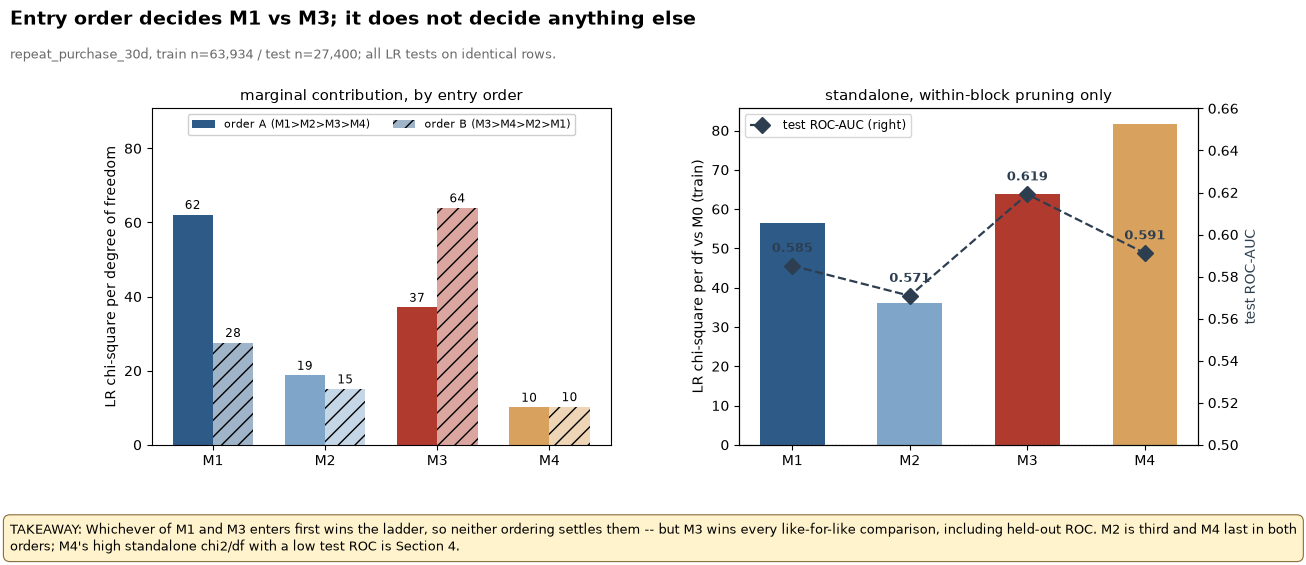

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.8))
fig.subplots_adjust(top=0.80, bottom=0.22, wspace=0.28)
blks   = BLOCK_ORDER_A
colors = {"M1 first order": "#2E5A88", "M2 first-order session": "#7FA6C9",
          "M3 pre-t0 browsing": "#B03A2E", "M4 cadence": "#D8A25E"}

ax = axes[0]
w, xs = 0.36, np.arange(len(blks))
a_vals = [float(ladderA.set_index("block_added").loc[b, "chi2_per_df"]) for b in blks]
b_vals = [float(ladderB.set_index("block_added").loc[b, "chi2_per_df"]) for b in blks]
ax.bar(xs - w/2, a_vals, w, color=[colors[b] for b in blks], label="order A (M1>M2>M3>M4)")
ax.bar(xs + w/2, b_vals, w, color=[colors[b] for b in blks], alpha=0.45, hatch="//",
       label="order B (M3>M4>M2>M1)")
for x, (va, vb) in enumerate(zip(a_vals, b_vals)):
    ax.text(x - w/2, va + 1.5, f"{va:.0f}", ha="center", fontsize=8.5)
    ax.text(x + w/2, vb + 1.5, f"{vb:.0f}", ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xticklabels([b.split(" ")[0] for b in blks])
ax.set_ylabel("LR chi-square per degree of freedom")
ax.set_ylim(0, max(a_vals + b_vals) * 1.42)
ax.set_title("marginal contribution, by entry order", fontsize=10.5)
ax.legend(fontsize=8.2, loc="upper center", ncol=2, framealpha=0.95)

ax = axes[1]
s = standalone.set_index("block").loc[blks]
ax.bar(xs, s.chi2_per_df, 0.55, color=[colors[b] for b in blks])
ax.set_xticks(xs); ax.set_xticklabels([b.split(" ")[0] for b in blks])
ax.set_ylabel("LR chi-square per df vs M0 (train)")
ax2 = ax.twinx()
ax2.plot(xs, s.test_ROC, "D--", color="#2C3E50", ms=8, lw=1.6, label="test ROC-AUC (right)")
for x, v in zip(xs, s.test_ROC):
    ax2.annotate(f"{v:.3f}", (x, v), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9, color="#2C3E50", fontweight="bold")
ax2.set_ylabel("test ROC-AUC", color="#2C3E50"); ax2.set_ylim(0.50, 0.66)
ax2.axhline(0.5, color="#95A5A6", lw=1, ls=":")
ax2.legend(fontsize=8.5, loc="upper left")
ax.set_title("standalone, within-block pruning only", fontsize=10.5)

add_title(fig, "Entry order decides M1 vs M3; it does not decide anything else",
          f"repeat_purchase_30d, train n={len(tr30):,} / test n={len(te30):,}; all LR tests on identical rows.")
add_takeaway(fig, "Whichever of M1 and M3 enters first wins the ladder, so neither ordering settles them -- "
                  "but M3 wins every like-for-like comparison, including held-out ROC. M2 is third and M4 "
                  "last in both orders; M4's high standalone chi2/df with a low test ROC is Section 4.")
save(fig, "nb06_ladder_both_orders"); plt.show()

### What the two ladders say — and where they disagree

**The top two flip. The bottom two do not.**

| block | χ²/df entering **first** | χ²/df entering **late** | standalone χ²/df | standalone test ROC |
|---|---|---|---|---|
| M3 pre-`t0` browsing | **63.9** (order B, 1st) | 37.1 (order A, 3rd) | 63.9 | **0.6191** |
| M1 first order | **62.2** (order A, 1st) | 27.6 (order B, 4th) | 56.4 | 0.5852 |
| M2 first-order session | — | 18.7 (A, 2nd) / 15.1 (B, 3rd) | 36.1 | 0.5709 |
| M4 cadence | — | 10.3 (B, 2nd) / 10.1 (A, 4th) | **81.6** | 0.5911 |

Read order A on its own and the answer is **M1**: first-order characteristics buy 62.2 χ²
per df against M3's 37.1. Read order B on its own and the answer is **M3**: 63.9 against
M1's 27.6. Whichever block enters first wins. **Neither ladder alone settles M1 versus M3**,
and 05's addendum was right to demand both — the brief's specified ordering does not merely
flatter M1, it inverts the headline.

What survives the ordering:

1. **M2 is third and M4 is last in both orders**, and at all three horizons. Those two
   positions are not an artefact of entry.
2. **M3 beats M1 in every order-controlled comparison.** Entering first: 63.9 vs 62.2.
   Entering late: 37.1 vs 27.6. Standalone: 63.9 vs 56.4, and on held-out discrimination
   0.6191 vs 0.5852 test ROC-AUC. Three like-for-like comparisons, one direction. The
   ranking that flips is the *within-order* one, which compares a block entering first
   against a block entering third — and that comparison was never meaningful.
3. **M4 is the only block whose contribution is indifferent to position**: 10.3 χ²/df
   entering second, 10.1 entering last. A block that adds the same tiny amount no matter
   what precedes it is nearly orthogonal to the outcome, not merely crowded out.
4. **M3 alone gets most of the way to the final model.** After M3 and nothing else, order B
   is at 0.6192 test ROC-AUC; the full four-block model reaches 0.6278. The other three
   blocks together are worth 0.009 ROC-AUC.
5. **M4 standalone is the anomaly.** The highest train χ²/df of any block, 81.6, and the
   second-lowest test ROC. That combination usually means overfitting. Here it does not.

## 4. Why M4 looks strong alone and adds nothing: it is M3 volume, renamed

`cad_n_hist_gaps` is documented as the count of historical inter-session gaps. Its
Spearman correlation with `pre_n_sessions` is exactly 1.0000 in 05's own table, which is
usually where such an observation stops. It should not stop there — a Spearman of exactly
1 across 42,190 rows is not a strong relationship, it is a deterministic one.

In [11]:
# Durable names -- Section 12 re-checks these, and short names get clobbered downstream.
cad_gaps  = pd.to_numeric(D30.cad_n_hist_gaps,     errors="coerce")
pre_sess  = pd.to_numeric(D30.pre_n_sessions,      errors="coerce")
cad_dgaps = pd.to_numeric(D30.cad_day_n_hist_gaps, errors="coerce")
pre_days  = pd.to_numeric(D30.pre_n_active_days,   errors="coerce")
BOTH_SESS = cad_gaps.notna()  & pre_sess.notna()
BOTH_DAYS = cad_dgaps.notna() & pre_days.notna()
IDENT_DIFF = pre_sess[BOTH_SESS] - cad_gaps[BOTH_SESS]
IDENT_N    = int(BOTH_SESS.sum())
IDENT_EXACT_PCT = 100 * float((IDENT_DIFF == 2).mean())

ident = pd.DataFrame([
    dict(m4_feature="cad_n_hist_gaps", m3_feature="pre_n_sessions", n_both_defined=IDENT_N,
         relation="pre_n_sessions - 2", share_exact_pct=IDENT_EXACT_PCT,
         spearman_in_05=1.0000, m4_train_auc=train_uni["cad_n_hist_gaps"],
         m3_train_auc=train_uni["pre_n_sessions"]),
    dict(m4_feature="cad_day_n_hist_gaps", m3_feature="pre_n_active_days", n_both_defined=int(BOTH_DAYS.sum()),
         relation="pre_n_active_days - 1 (not exact)",
         share_exact_pct=100 * float((pre_days[BOTH_DAYS] - cad_dgaps[BOTH_DAYS] == 1).mean()),
         spearman_in_05=0.9676, m4_train_auc=train_uni["cad_day_n_hist_gaps"],
         m3_train_auc=train_uni["pre_n_active_days"]),
    dict(m4_feature="has_session_cadence", m3_feature="pre_n_sessions >= 2", n_both_defined=len(D30),
         relation="indicator that the same count exceeds 1",
         share_exact_pct=100 * float((D30.has_session_cadence.astype(int) == (pre_sess >= 2).astype(int)).mean()),
         spearman_in_05=np.nan, m4_train_auc=train_uni["has_session_cadence"],
         m3_train_auc=np.nan),
])
show_df(ident.round(4), "nb06_m4_m3_identity")
print()
print(f"cad_n_hist_gaps == pre_n_sessions - 2 on {IDENT_EXACT_PCT:.4f}% of the "
      f"{IDENT_N:,} rows where both are defined -- every single one.")
print("It is an identity, not a correlation: the gaps between a user's pre-t0 sessions are")
print("counted from the same sessions M3 already counts. M4's session-cadence 'volume' feature")
print("carries no information M3 does not already have.")
print()
print("CONSEQUENCE. The global pruning rule (2C) therefore assigns both features to M3, which is")
print("why M4 adds ~122 chi2 on 13 df in BOTH ladder orders while scoring the highest standalone")
print("chi2/df of any block: standalone, it is allowed to keep M3's volume counts. This is also")
print("why 05's best-per-block table put cad_day_n_hist_gaps (AUC 0.5735) at the head of M4 --")
print("that number was never a cadence result.")
print()
print("What genuinely belongs to M4 -- the TIMING features -- is weak on its own:")
tim = pd.DataFrame([dict(feature=f, block="M4 cadence", train_univariate_AUC=train_uni[f],
                         missing_pct_train=100 * float(tr30[f].isna().mean()))
                    for f in ["cad_median_gap_d", "cad_iqr_gap_d", "cad_regularity", "cad_lapse_ratio",
                              "gap_before_purchase_visit", "cad_day_median_gap_d", "cad_day_lapse_ratio",
                              "gap_before_purchase_day"]]).sort_values("train_univariate_AUC", ascending=False)
show_df(tim.round(4), "nb06_m4_timing_only")

            m4_feature           m3_feature  n_both_defined                                 relation  share_exact_pct  spearman_in_05  m4_train_auc  \
0      cad_n_hist_gaps       pre_n_sessions           42190                       pre_n_sessions - 2         100.0000          1.0000        0.5311   
1  cad_day_n_hist_gaps    pre_n_active_days           43092        pre_n_active_days - 1 (not exact)          20.9807          0.9676        0.5772   
2  has_session_cadence  pre_n_sessions >= 2           91334  indicator that the same count exceeds 1          82.3264             NaN        0.5715   

   m3_train_auc  
0        0.5874  
1        0.5994  
2           NaN  

cad_n_hist_gaps == pre_n_sessions - 2 on 100.0000% of the 42,190 rows where both are defined -- every single one.
It is an identity, not a correlation: the gaps between a user's pre-t0 sessions are
counted from the same sessions M3 already counts. M4's session-cadence 'volume' feature
carries no information M3 does not a

,feature,block,train_univariate_AUC,missing_pct_train
0,cad_median_gap_d,M4 cadence,0.5580,54.4186
1,cad_iqr_gap_d,M4 cadence,0.5561,54.4186
4,gap_before_purchase_visit,M4 cadence,0.5385,54.0698
5,cad_day_median_gap_d,M4 cadence,0.5285,74.0248
2,cad_regularity,M4 cadence,0.5275,54.4186
3,cad_lapse_ratio,M4 cadence,0.5220,54.4186
6,cad_day_lapse_ratio,M4 cadence,0.5136,74.0248
7,gap_before_purchase_day,M4 cadence,0.5094,63.3372


## 5. Is the model just a one-dimensional activity-intensity score?

05's univariate top ten is entirely M3 volume counts — `pre_n_products`, `pre_n_events`,
`pre_n_cart_ev`, `pre_n_categories`, `pre_p_carted`, `pre_n_removals`, `pre_n_active_days`,
`pre_n_brands`, `tenure_d` — and 23 pairs sit at |ρ| ≥ 0.90. That is the signature of one
latent quantity measured nine ways: *how much this user did before they bought*.

The test: extract the first principal component of eleven M3 volume features (fitted on
train only, on log1p scale, standardised on train), score train and test with it, and ask
whether the 62-feature logistic beats that single number. If it does not, the finding is
that repeat purchase here is predicted by pre-purchase engagement **volume** and by little
else — which is consistent with 01 (abandonment *volume* survives, *type* does not) and
with SPINE-1's falsification.

In [12]:
VOL = ["pre_n_products", "pre_n_events", "pre_n_cart_ev", "pre_n_categories", "pre_p_carted",
       "pre_n_removals", "pre_n_active_days", "pre_n_brands", "tenure_d", "pre_n_sessions",
       "pre_n_view_ev"]
Vtr = np.log1p(tr30[VOL].apply(pd.to_numeric, errors="coerce").clip(lower=0))
Vte = np.log1p(te30[VOL].apply(pd.to_numeric, errors="coerce").clip(lower=0))
obs = Vtr.notna().all(1)
pc_mu, pc_sd = Vtr[obs].mean(), Vtr[obs].std(ddof=0).replace(0, 1.0)
PC = PCA(n_components=5, random_state=SEED).fit(((Vtr[obs] - pc_mu) / pc_sd).to_numpy())

def pc1_score(V):
    Z = (V - pc_mu) / pc_sd
    ok = Z.notna().all(1).to_numpy()
    out = np.full(len(V), np.nan)
    out[ok] = PC.transform(Z[ok].to_numpy())[:, 0]
    return out

pc1_tr, pc1_te = pc1_score(Vtr), pc1_score(Vte)
load = pd.DataFrame({"feature": VOL, "PC1_loading": PC.components_[0].round(3),
                     "univariate_AUC_train": [train_uni[f] for f in VOL]}).sort_values("PC1_loading", ascending=False)
show_df(load.round(4), "nb06_pc1_loadings", max_rows=12)
print()
print(f"PC1 explains {100*PC.explained_variance_ratio_[0]:.1f}% of the variance of these 11 features "
      f"(PC1+PC2: {100*PC.explained_variance_ratio_[:2].sum():.1f}%).")
print(f"All 11 loadings are POSITIVE and of similar size -- PC1 is a plain intensity score, not a contrast.")
print(f"PC1 univariate AUC: train {uni_auc(pc1_tr, y_tr30):.4f}, test {uni_auc(pc1_te, y_te30):.4f}")

              feature  PC1_loading  univariate_AUC_train
1        pre_n_events        0.350                0.6096
0      pre_n_products        0.347                0.6101
3    pre_n_categories        0.327                0.6050
4        pre_p_carted        0.319                0.6031
2       pre_n_cart_ev        0.311                0.6051
7        pre_n_brands        0.311                0.5957
5      pre_n_removals        0.304                0.6037
10      pre_n_view_ev        0.292                0.5701
6   pre_n_active_days        0.261                0.5994
9      pre_n_sessions        0.240                0.5874
8            tenure_d        0.226                0.6002

PC1 explains 68.5% of the variance of these 11 features (PC1+PC2: 81.4%).
All 11 loadings are POSITIVE and of similar size -- PC1 is a plain intensity score, not a contrast.
PC1 univariate AUC: train 0.6180, test 0.6145


## 6. LightGBM — one job, one question

Does nonlinearity buy anything over the logistic M4? LightGBM sees all 81 eligible features
(no collinearity pruning — binding rule 5 exempts it) with native NaN handling, so no
sentinel is needed. Tuning is modest: a 16-point grid over `num_leaves`,
`min_child_samples`, `feature_fraction` and `lambda_l2`, selected on **average precision on
the validation fold**, with early stopping at 100 rounds. The test fold is not touched.
The winner is then refit on the full train fold at the selected round count.

In [13]:
def lgb_matrix(base, others, y_base):
    """81 eligible features; categoricals target-encoded on `base` only (binding rule 4)."""
    out = []
    for df in [base] + list(others):
        X = pd.DataFrame(index=df.index)
        for c in ELIGIBLE_COLS:
            if c in CAT_COLS:
                continue
            X[c] = pd.to_numeric(df[c], errors="coerce").astype(float)
        out.append(X)
    prior = float(np.mean(y_base))
    for c in CAT_COLS:
        a, _ = target_encode(base[c], base[c], y_base, prior)
        out[0][c + "__te"] = a
        for i, df in enumerate(others, 1):
            _, bmap = target_encode(base[c], df[c], y_base, prior)
            out[i][c + "__te"] = bmap
    return out

y_s = trs30[TARGET].astype(int).to_numpy(); y_v = va30[TARGET].astype(int).to_numpy()
Xs, Xv, Xt = lgb_matrix(trs30, [va30, te30], y_s)

GRID = [dict(num_leaves=nl, min_child_samples=mcs, learning_rate=0.05, feature_fraction=ff,
             bagging_fraction=0.8, bagging_freq=1, lambda_l2=l2)
        for nl in (15, 31) for mcs in (100, 300) for ff in (0.6, 0.9) for l2 in (1.0, 10.0)]
BASE_P = dict(objective="binary", metric="average_precision", verbosity=-1, seed=SEED,
              deterministic=True, force_col_wise=True, num_threads=4)

tuning = []
for g in GRID:
    booster = lgb.train({**BASE_P, **g}, lgb.Dataset(Xs, y_s), num_boost_round=2000,
                        valid_sets=[lgb.Dataset(Xv, y_v)],
                        callbacks=[lgb.early_stopping(100, verbose=False)])
    tuning.append(dict(**g, best_iter=booster.best_iteration,
                       valid_AP=average_precision_score(
                           y_v, booster.predict(Xv, num_iteration=booster.best_iteration))))
tune_tbl = pd.DataFrame(tuning).sort_values("valid_AP", ascending=False).reset_index(drop=True)
show_df(tune_tbl.round(5), "nb06_lgbm_tuning", max_rows=6)

BEST = tune_tbl.iloc[0]
BEST_PARAMS = {k: BEST[k] for k in ["num_leaves", "min_child_samples", "learning_rate",
                                    "feature_fraction", "bagging_fraction", "bagging_freq", "lambda_l2"]}
BEST_PARAMS["num_leaves"] = int(BEST_PARAMS["num_leaves"])
BEST_PARAMS["min_child_samples"] = int(BEST_PARAMS["min_child_samples"])
BEST_PARAMS["bagging_freq"] = int(BEST_PARAMS["bagging_freq"])
BEST_ITER = int(BEST.best_iter)
print()
print(f"selected on VALIDATION average precision: {BEST_PARAMS}, {BEST_ITER} rounds "
      f"(valid AP {BEST.valid_AP:.4f}); spread across the 16-point grid was "
      f"{tune_tbl.valid_AP.max()-tune_tbl.valid_AP.min():.4f} AP -- tuning is not where the result lives.")

# refit on the FULL train fold at the selected round count, so it is compared to the
# logistic on equal footing (both fitted on n = {len(tr30)}).
Xtr_l, Xte_l = lgb_matrix(tr30, [te30], y_tr30)
LGBM = lgb.train({**BASE_P, **BEST_PARAMS}, lgb.Dataset(Xtr_l, y_tr30), num_boost_round=BEST_ITER)
p_lgb = LGBM.predict(Xte_l)
print(f"LightGBM refit on full train ({len(tr30):,} rows, {Xtr_l.shape[1]} features), {BEST_ITER} rounds.")

   num_leaves  min_child_samples  learning_rate  feature_fraction  bagging_fraction  bagging_freq  lambda_l2  best_iter  valid_AP
0          15                300           0.05               0.9               0.8             1       10.0        127   0.15838
1          31                100           0.05               0.6               0.8             1        1.0         92   0.15775
2          15                100           0.05               0.6               0.8             1        1.0         99   0.15774
3          31                100           0.05               0.9               0.8             1        1.0         91   0.15764
4          15                300           0.05               0.6               0.8             1       10.0        238   0.15744
5          15                100           0.05               0.9               0.8             1        1.0         99   0.15731

selected on VALIDATION average precision: {'num_leaves': 15, 'min_child_samples': 300, 'l

LightGBM refit on full train (63,934 rows, 81 features), 127 rounds.


## 7. Evaluation, with the naive baselines in the same table

Per CLAUDE.md principle 7, **PR-AUC / average precision is primary** against the 13.73%
base rate and ROC-AUC is secondary. Every comparison carries a paired bootstrap CI over the
test fold (2,000 resamples, seed 42) because at n = 27,400 a p-value would be meaningless
(principle 12).

Four reference points, all fitted on train only:

- **prevalence only** — the train base rate for everyone. AP equals the test base rate.
- **first-order value quintile** — the naive baseline the brief names, cut at train quintiles.
- **`pre_n_products` alone** — 05's univariate champion, the one-feature rule that the
  shipped model must beat to justify existing (05's binding rule).
- **PC1 volume score** — the single activity-intensity component from Section 5.

In [14]:
allf30 = [c for b in BLOCK_ORDER_A for c in BLOCKS[b]]
Xtr_full, Xall = make_matrix(tr30, pd.concat([va30, te30]), allf30, y_tr30)
plan30 = indicator_plan(Xtr_full, BLOCKS, BLOCK_ORDER_A)
Xtr_full, Xall = attach_indicators(Xtr_full, Xall, plan30)
M4_RES, M4_USED, M4_MU, M4_SD = fit_logit(Xtr_full, y_tr30)
p_all = predict_logit(M4_RES, M4_USED, M4_MU, M4_SD, Xall)
p_va, p_m4 = p_all[:len(va30)], p_all[len(va30):]
p_m4_train = predict_logit(M4_RES, M4_USED, M4_MU, M4_SD, Xtr_full)

def fit_simple(cols_tr, cols_te):
    """Small logistic on a couple of columns with sentinel+indicator, fitted on train only."""
    A = np.asarray(cols_tr, float).reshape(len(cols_tr), -1)
    B = np.asarray(cols_te, float).reshape(len(cols_te), -1)
    Za = np.c_[np.nan_to_num(A), np.isnan(A).astype(float)]
    Zb = np.c_[np.nan_to_num(B), np.isnan(B).astype(float)]
    mu_, sd_ = Za.mean(0), Za.std(0); sd_[sd_ == 0] = 1.0
    lr = LogisticRegression(max_iter=3000).fit((Za - mu_) / sd_, y_tr30)
    return lr.predict_proba((Zb - mu_) / sd_)[:, 1]

q = np.nanquantile(pd.to_numeric(tr30.fo_value, errors="coerce"), [.2, .4, .6, .8])
qa = pd.get_dummies(np.digitize(pd.to_numeric(tr30.fo_value, errors="coerce"), q)).reindex(columns=range(5), fill_value=0).to_numpy(float)
qb = pd.get_dummies(np.digitize(pd.to_numeric(te30.fo_value, errors="coerce"), q)).reindex(columns=range(5), fill_value=0).to_numpy(float)
_lr = LogisticRegression(max_iter=3000).fit(qa, y_tr30)
p_quint = _lr.predict_proba(qb)[:, 1]
p_1feat = fit_simple(pd.to_numeric(tr30.pre_n_products, errors="coerce"),
                     pd.to_numeric(te30.pre_n_products, errors="coerce"))
p_pc1   = fit_simple(pc1_tr, pc1_te)
p_prev  = np.full(len(te30), y_tr30.mean())

MODELS = {
    "BASE  prevalence only":                     p_prev,
    "NAIVE first-order value quintile":          p_quint,
    "NAIVE pre_n_products alone (1 feature)":    p_1feat,
    "NAIVE PC1 activity-intensity score":        p_pc1,
    "SHIPPED  logistic M4 (62 features)":        p_m4,
    "LightGBM (81 features)":                    p_lgb,
}
base_rate = y_te30.mean()
ev_rows = []
for nm, p in MODELS.items():
    ev_rows.append(dict(model=nm, AP=average_precision_score(y_te30, p),
                        AP_lift_vs_base=average_precision_score(y_te30, p) / base_rate,
                        ROC_AUC=roc_auc_score(y_te30, p), Brier=brier_score_loss(y_te30, p),
                        mean_pred_pct=100 * p.mean()))
ev = pd.DataFrame(ev_rows)
ev["pct_of_shipped_AP_excess"] = 100 * (ev.AP - base_rate) / (float(ev.loc[ev.model.str.startswith("SHIPPED"), "AP"].iloc[0]) - base_rate)
print(f"TEST FOLD  n={len(te30):,}   positive rate {100*base_rate:.3f}%   "
      f"(05's univariate ceiling for reference: {UNI_CEIL:.4f} ROC-AUC on {UNI_FEAT}, in-sample over all 91,334)")
print("=" * 122)
show_df(ev.round(4), "nb06_evaluation_vs_baselines", max_rows=10)

TEST FOLD  n=27,400   positive rate 11.653%   (05's univariate ceiling for reference: 0.6097 ROC-AUC on pre_n_products, in-sample over all 91,334)
                                    model      AP  AP_lift_vs_base  ROC_AUC   Brier  mean_pred_pct  pct_of_shipped_AP_excess
0                   BASE  prevalence only  0.1165           1.0000   0.5000  0.1038        14.6198                    0.0000
1        NAIVE first-order value quintile  0.1355           1.1627   0.5638  0.1032        14.3669                   29.4454
2  NAIVE pre_n_products alone (1 feature)  0.1643           1.4102   0.6051  0.1029        14.5008                   74.2236
3      NAIVE PC1 activity-intensity score  0.1684           1.4448   0.6145  0.1022        14.5261                   80.4890
4      SHIPPED  logistic M4 (62 features)  0.1809           1.5526   0.6278  0.1014        13.6906                  100.0000
5                  LightGBM (81 features)  0.1849           1.5866   0.6412  0.1002        11.9448     

,model,AP,AP_lift_vs_base,ROC_AUC,Brier,mean_pred_pct,pct_of_shipped_AP_excess
0,BASE prevalence only,0.1165,1.0000,0.5000,0.1038,14.6198,0.0000
1,NAIVE first-order value quintile,0.1355,1.1627,0.5638,0.1032,14.3669,29.4454
2,NAIVE pre_n_products alone (1 feature),0.1643,1.4102,0.6051,0.1029,14.5008,74.2236
3,NAIVE PC1 activity-intensity score,0.1684,1.4448,0.6145,0.1022,14.5261,80.4890
4,SHIPPED logistic M4 (62 features),0.1809,1.5526,0.6278,0.1014,13.6906,100.0000
5,LightGBM (81 features),0.1849,1.5866,0.6412,0.1002,11.9448,106.1536


In [15]:
rng = np.random.default_rng(SEED)
BOOT = 2000
boot_idx = [rng.integers(0, len(y_te30), len(y_te30)) for _ in range(BOOT)]

def paired_delta(pA, pB):
    dA = np.empty(BOOT); dR = np.empty(BOOT)
    for j, i in enumerate(boot_idx):
        dA[j] = average_precision_score(y_te30[i], pB[i]) - average_precision_score(y_te30[i], pA[i])
        dR[j] = roc_auc_score(y_te30[i], pB[i]) - roc_auc_score(y_te30[i], pA[i])
    return dA, dR

COMPARISONS = [
    ("logistic M4  -  prevalence only",              p_prev,  p_m4),
    ("logistic M4  -  first-order value quintile",   p_quint, p_m4),
    ("logistic M4  -  pre_n_products alone",         p_1feat, p_m4),
    ("logistic M4  -  PC1 activity score",           p_pc1,   p_m4),
    ("PC1 score    -  pre_n_products alone",         p_1feat, p_pc1),
    ("LightGBM     -  logistic M4",                  p_m4,    p_lgb),
]
crows = []
for nm, a, b in COMPARISONS:
    dA, dR = paired_delta(a, b)
    crows.append(dict(comparison=nm,
                      dAP=np.median(dA), dAP_lo=np.percentile(dA, 2.5), dAP_hi=np.percentile(dA, 97.5),
                      dAP_excludes_0=bool(np.percentile(dA, 2.5) > 0 or np.percentile(dA, 97.5) < 0),
                      dROC=np.median(dR), dROC_lo=np.percentile(dR, 2.5), dROC_hi=np.percentile(dR, 97.5),
                      dROC_excludes_0=bool(np.percentile(dR, 2.5) > 0 or np.percentile(dR, 97.5) < 0)))
comp = pd.DataFrame(crows)
print(f"PAIRED BOOTSTRAP, {BOOT:,} resamples of the test fold, seed {SEED}. PRIMARY metric is dAP.")
print("=" * 122)
show_df(comp.round(4), "nb06_bootstrap_model_comparisons", max_rows=10)

SHIP = "logistic M4"
print()
print("THE SHIP DECISION")
print("-" * 122)
lg = comp.set_index("comparison").loc["LightGBM     -  logistic M4"]
nf = comp.set_index("comparison").loc["logistic M4  -  pre_n_products alone"]
pcc = comp.set_index("comparison").loc["logistic M4  -  PC1 activity score"]
print(f"  LightGBM vs logistic M4 : dAP {lg.dAP:+.4f} [{lg.dAP_lo:+.4f}, {lg.dAP_hi:+.4f}] -- "
      f"{'EXCLUDES' if lg.dAP_excludes_0 else 'INCLUDES'} zero on the PRIMARY metric.")
print(f"                            dROC {lg.dROC:+.4f} [{lg.dROC_lo:+.4f}, {lg.dROC_hi:+.4f}] -- secondary only.")
print("      -> Nonlinearity does not buy a detectable gain in average precision. SHIP THE LOGISTIC M4.")
print(f"  Logistic M4 vs the one-feature rule : dAP {nf.dAP:+.4f} [{nf.dAP_lo:+.4f}, {nf.dAP_hi:+.4f}] -- "
      f"{'EXCLUDES' if nf.dAP_excludes_0 else 'INCLUDES'} zero.")
print("      -> The model clears 05's binding rule. This is NOT a rejection.")
print(f"  Logistic M4 vs PC1 alone : dAP {pcc.dAP:+.4f} [{pcc.dAP_lo:+.4f}, {pcc.dAP_hi:+.4f}] -- "
      f"{'EXCLUDES' if pcc.dAP_excludes_0 else 'INCLUDES'} zero.")
print(f"      -> Real, and small: PC1 alone already recovers "
      f"{float(ev.set_index('model').loc['NAIVE PC1 activity-intensity score','pct_of_shipped_AP_excess']):.0f}% of the "
      f"shipped model's excess AP over the base rate; one raw feature recovers "
      f"{float(ev.set_index('model').loc['NAIVE pre_n_products alone (1 feature)','pct_of_shipped_AP_excess']):.0f}%.")

PAIRED BOOTSTRAP, 2,000 resamples of the test fold, seed 42. PRIMARY metric is dAP.
                                   comparison     dAP  dAP_lo  dAP_hi  dAP_excludes_0    dROC  dROC_lo  dROC_hi  dROC_excludes_0
0             logistic M4  -  prevalence only  0.0647  0.0570  0.0738            True  0.1280   0.1175   0.1382             True
1  logistic M4  -  first-order value quintile  0.0457  0.0381  0.0545            True  0.0639   0.0521   0.0762             True
2        logistic M4  -  pre_n_products alone  0.0167  0.0099  0.0237            True  0.0228   0.0140   0.0315             True
3          logistic M4  -  PC1 activity score  0.0126  0.0066  0.0192            True  0.0135   0.0053   0.0211             True
4        PC1 score    -  pre_n_products alone  0.0040  0.0015  0.0065            True  0.0093   0.0062   0.0125             True
5                 LightGBM     -  logistic M4  0.0039 -0.0017  0.0101           False  0.0133   0.0076   0.0192             True

THE SHIP DEC

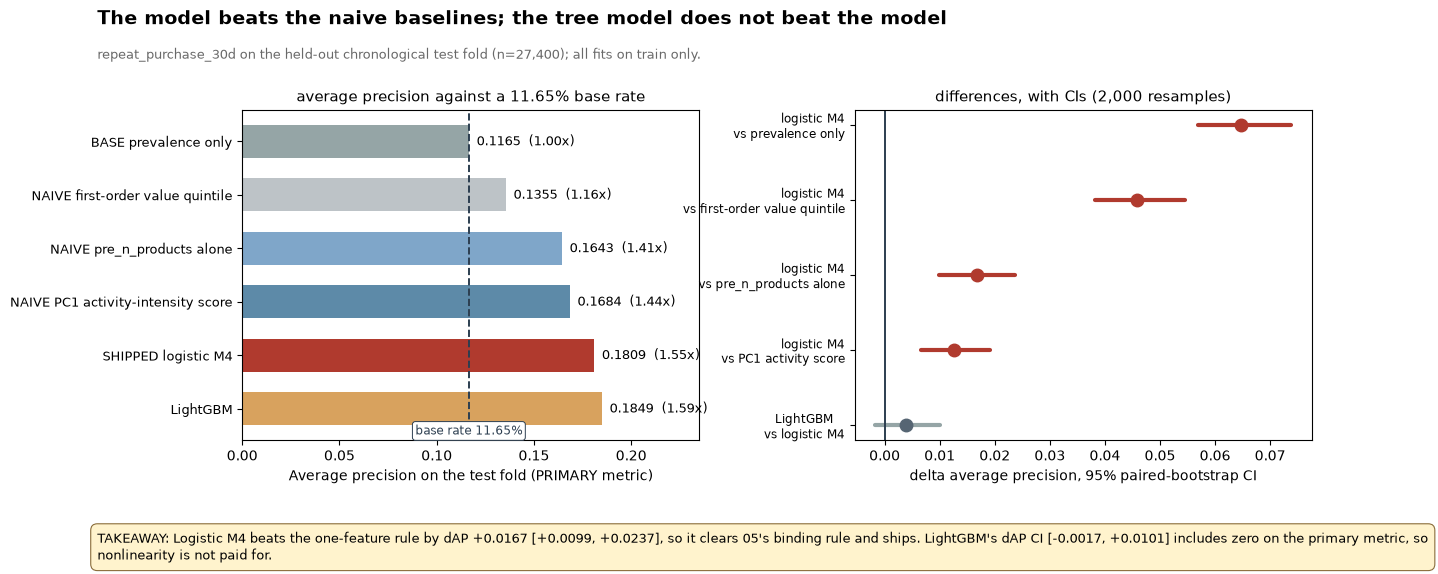

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.9))
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.34)

ax = axes[0]
order_m = ["BASE  prevalence only", "NAIVE first-order value quintile",
           "NAIVE pre_n_products alone (1 feature)", "NAIVE PC1 activity-intensity score",
           "SHIPPED  logistic M4 (62 features)", "LightGBM (81 features)"]
e = ev.set_index("model").loc[order_m]
cols = ["#95A5A6", "#BDC3C7", "#7FA6C9", "#5D8AA8", "#B03A2E", "#D8A25E"]
ax.barh(range(len(e)), e.AP, color=cols, height=0.62)
ax.axvline(base_rate, color="#2C3E50", ls="--", lw=1.4)
ax.annotate(f"base rate {100*base_rate:.2f}%", xy=(base_rate, 5.42), fontsize=8.5, color="#2C3E50",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#2C3E50", lw=0.7))
for i, (v, l_) in enumerate(zip(e.AP, e.AP_lift_vs_base)):
    ax.text(v + 0.004, i, f"{v:.4f}  ({l_:.2f}x)", va="center", fontsize=9)
ax.set_yticks(range(len(e)))
ax.set_yticklabels([m.replace("  ", " ").replace(" (1 feature)", "").replace(" (62 features)", "")
                    .replace(" (81 features)", "") for m in e.index], fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("Average precision on the test fold (PRIMARY metric)")
ax.set_xlim(0, 0.235)
ax.set_title("average precision against a 11.65% base rate", fontsize=10.5)

ax = axes[1]
cc = comp.set_index("comparison")
lbls = ["logistic M4  -  prevalence only", "logistic M4  -  first-order value quintile",
        "logistic M4  -  pre_n_products alone", "logistic M4  -  PC1 activity score",
        "LightGBM     -  logistic M4"]
ys = np.arange(len(lbls))
for i, l_ in enumerate(lbls):
    r = cc.loc[l_]
    good = r.dAP_lo > 0
    ax.plot([r.dAP_lo, r.dAP_hi], [i, i], lw=3, color="#B03A2E" if good else "#95A5A6",
            solid_capstyle="round")
    ax.plot(r.dAP, i, "o", ms=9, color="#B03A2E" if good else "#566573")
ax.axvline(0, color="#2C3E50", lw=1.4)
ax.set_yticks(ys); ax.set_yticklabels([l_.replace("  -  ", "\n  vs ") for l_ in lbls], fontsize=8.5)
ax.invert_yaxis(); ax.set_xlabel("delta average precision, 95% paired-bootstrap CI")
ax.set_title("differences, with CIs (2,000 resamples)", fontsize=10.5)

add_title(fig, "The model beats the naive baselines; the tree model does not beat the model",
          "repeat_purchase_30d on the held-out chronological test fold (n=27,400); all fits on train only.")
add_takeaway(fig, "Logistic M4 beats the one-feature rule by dAP +0.0167 [+0.0099, +0.0237], so it clears 05's "
                  "binding rule and ships. LightGBM's dAP CI [-0.0017, +0.0101] includes zero on the primary "
                  "metric, so nonlinearity is not paid for.")
save(fig, "nb06_model_comparison"); plt.show()

## 8. Calibration, decile lift, and an operating point that is not 0.5

### 8A — Calibration

The raw model over-predicts on test by 2.0pp in the mean, and the miss is concentrated in
the top deciles. That is the base-rate drift from Section 1, not a fitting failure: train
runs at 14.62% positive and test at 11.65%, and the model is calibrated to the world it was
trained in.

The honest correction is an **intercept-only shift fitted on the validation fold** — the
last 20% of train, the most recent data available without touching test labels. It is a
monotone transform, so AP and ROC-AUC are unchanged by construction; only Brier and the
probability levels move. The oracle shift (fitted on the test labels) is reported alongside
purely as a bound on what recalibration could have bought, and is not used for anything.

In [17]:
def logit_of(p):
    p = np.clip(p, 1e-9, 1 - 1e-9)
    return np.log(p / (1 - p))

def prior_shift(p, target):
    lo = logit_of(p)
    return brentq(lambda a: (1 / (1 + np.exp(-(lo + a)))).mean() - target, -10, 10)

y_va30 = va30[TARGET].astype(int).to_numpy()
OFFSET_VAL  = prior_shift(p_va, y_va30.mean())
OFFSET_ORCL = prior_shift(p_m4, y_te30.mean())
p_m4_rc = 1 / (1 + np.exp(-(logit_of(p_m4) + OFFSET_VAL)))
p_m4_or = 1 / (1 + np.exp(-(logit_of(p_m4) + OFFSET_ORCL)))

cal_rows = []
for nm, p in [("raw (as fitted on train)", p_m4),
              ("intercept shift fitted on VALIDATION -- SHIPPED", p_m4_rc),
              ("oracle shift fitted on test labels -- DIAGNOSTIC ONLY", p_m4_or)]:
    cal_rows.append(dict(version=nm, mean_pred_pct=100 * p.mean(), observed_pct=100 * y_te30.mean(),
                         level_gap_pp=100 * (p.mean() - y_te30.mean()), Brier=brier_score_loss(y_te30, p),
                         AP=average_precision_score(y_te30, p), ROC_AUC=roc_auc_score(y_te30, p)))
show_df(pd.DataFrame(cal_rows).round(5), "nb06_calibration_versions")
print()
print(f"validation positive rate {100*y_va30.mean():.3f}%, test {100*y_te30.mean():.3f}% -- the validation fold")
print(f"is itself below test, so the shipped shift ({OFFSET_VAL:+.4f}) slightly OVER-corrects "
      f"(oracle would be {OFFSET_ORCL:+.4f}).")
print("Reported because a reader deserves to know the correction is approximate, and in which direction.")

def calib_table(y, p, q=10):
    b = pd.qcut(p, q, labels=False, duplicates="drop")
    u = np.unique(b)
    return pd.DataFrame(dict(bin=u + 1, n=[int((b == k).sum()) for k in u],
                             mean_pred_pct=[100 * p[b == k].mean() for k in u],
                             observed_pct=[100 * y[b == k].mean() for k in u])).assign(
        gap_pp=lambda t: t.mean_pred_pct - t.observed_pct)

cal_raw = calib_table(y_te30, p_m4); cal_rc = calib_table(y_te30, p_m4_rc)
show_df(cal_rc.round(3), "nb06_calibration_deciles_shipped")

                                             version  mean_pred_pct  observed_pct  level_gap_pp    Brier       AP  ROC_AUC
0                           raw (as fitted on train)       13.69060      11.65328       2.03732  0.10136  0.18093  0.62783
1    intercept shift fitted on VALIDATION -- SHIPPED       10.18767      11.65328      -1.46561  0.10089  0.18093  0.62783
2  oracle shift fitted on test labels -- DIAGNOST...       11.65328      11.65328       0.00000  0.10075  0.18093  0.62783

validation positive rate 10.346%, test 11.653% -- the validation fold
is itself below test, so the shipped shift (-0.3466) slightly OVER-corrects (oracle would be -0.1910).
Reported because a reader deserves to know the correction is approximate, and in which direction.
   bin     n  mean_pred_pct  observed_pct  gap_pp
0    1  2740          4.036         5.876  -1.840
1    2  2740          5.587         6.533  -0.946
2    3  2740          6.527         7.555  -1.028
3    4  2740          7.463         

,bin,n,mean_pred_pct,observed_pct,gap_pp
0,1,2740,4.036,5.876,-1.840
1,2,2740,5.587,6.533,-0.946
2,3,2740,6.527,7.555,-1.028
3,4,2740,7.463,8.978,-1.515
4,5,2740,8.436,10.401,-1.965
5,6,2740,9.520,11.606,-2.086
6,7,2740,10.858,13.285,-2.426
7,8,2740,12.688,14.416,-1.728
8,9,2740,15.410,15.949,-0.539
9,10,2740,21.351,21.934,-0.584


In [18]:
def decile_lift(y, p):
    o = np.argsort(-p, kind="stable"); yy = y[o]; pp = p[o]; n = len(y); base = y.mean(); cum = 0
    rows = []
    for i in range(10):
        s = slice(i * n // 10, (i + 1) * n // 10)
        cum += yy[s].sum()
        rows.append(dict(decile=i + 1, n=len(yy[s]), n_repeaters=int(yy[s].sum()),
                         observed_rate_pct=100 * yy[s].mean(), mean_predicted_pct=100 * pp[s].mean(),
                         lift_vs_base=yy[s].mean() / base, cumulative_capture_pct=100 * cum / yy.sum()))
    return pd.DataFrame(rows)

dec = decile_lift(y_te30, p_m4_rc)
print(f"DECILE LIFT -- shipped logistic M4, test fold, base rate {100*base_rate:.2f}%")
print("=" * 110)
show_df(dec.round(3), "nb06_decile_lift")
dec1f = decile_lift(y_te30, p_1feat)
print()
print(f"  decile-1 lift: shipped {dec.lift_vs_base.iloc[0]:.3f}x   vs one-feature rule "
      f"{dec1f.lift_vs_base.iloc[0]:.3f}x   vs random 1.000x")
print(f"  top-3-decile capture: shipped {dec.cumulative_capture_pct.iloc[2]:.1f}% of all repeaters "
      f"vs {dec1f.cumulative_capture_pct.iloc[2]:.1f}% and 30.0% at random")
print(f"  bottom decile runs at {dec.observed_rate_pct.iloc[-1]:.2f}% -- a {dec.lift_vs_base.iloc[0]/dec.lift_vs_base.iloc[-1]:.2f}x "
      f"spread top to bottom. Real separation, on a weak signal.")

DECILE LIFT -- shipped logistic M4, test fold, base rate 11.65%
   decile     n  n_repeaters  observed_rate_pct  mean_predicted_pct  lift_vs_base  cumulative_capture_pct
0       1  2740          601             21.934              21.351         1.882                  18.822
1       2  2740          437             15.949              15.410         1.369                  32.509
2       3  2740          395             14.416              12.688         1.237                  44.879
3       4  2740          364             13.285              10.858         1.140                  56.279
4       5  2740          318             11.606               9.520         0.996                  66.239
5       6  2740          285             10.401               8.436         0.893                  75.164
6       7  2740          246              8.978               7.463         0.770                  82.869
7       8  2740          207              7.555               6.527         0.648       

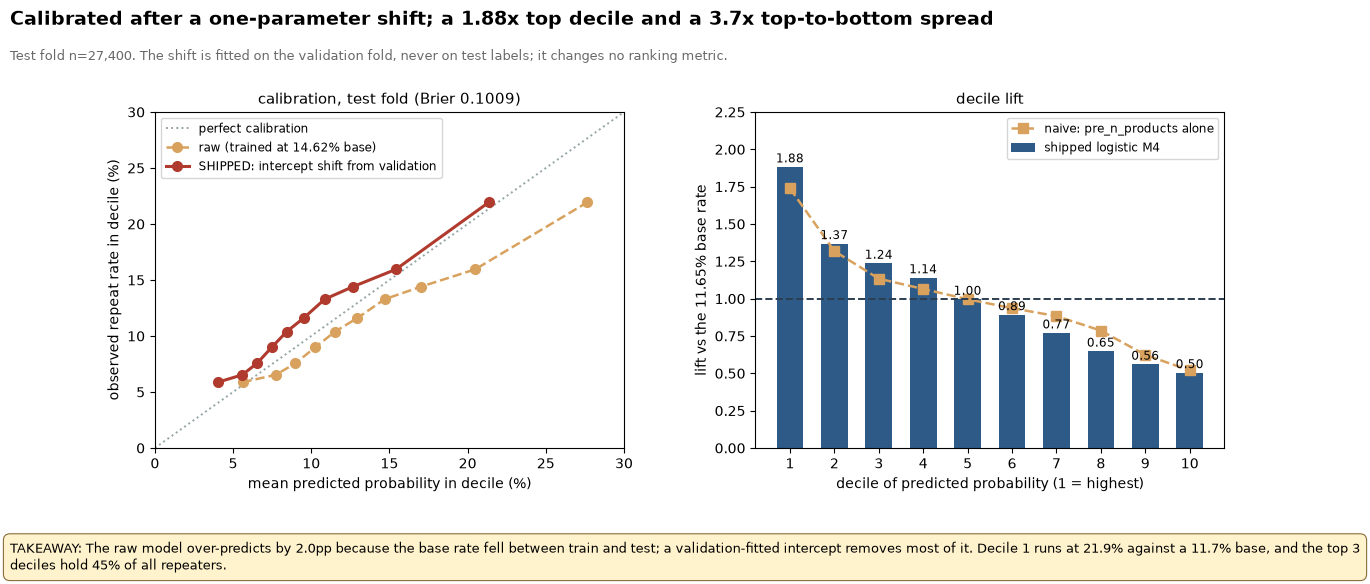

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.0))
fig.subplots_adjust(top=0.80, bottom=0.24, wspace=0.28)

ax = axes[0]
ax.plot([0, 30], [0, 30], color="#95A5A6", ls=":", lw=1.4, label="perfect calibration")
ax.plot(cal_raw.mean_pred_pct, cal_raw.observed_pct, "o--", color="#D8A25E", lw=1.8, ms=7,
        label="raw (trained at 14.62% base)")
ax.plot(cal_rc.mean_pred_pct, cal_rc.observed_pct, "o-", color="#B03A2E", lw=2.2, ms=7,
        label="SHIPPED: intercept shift from validation")
ax.set_xlabel("mean predicted probability in decile (%)")
ax.set_ylabel("observed repeat rate in decile (%)")
ax.set_xlim(0, 30); ax.set_ylim(0, 30)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title(f"calibration, test fold (Brier {brier_score_loss(y_te30, p_m4_rc):.4f})", fontsize=10.5)

ax = axes[1]
xs = np.arange(1, 11)
ax.bar(xs, dec.lift_vs_base, 0.6, color="#2E5A88", label="shipped logistic M4")
ax.plot(xs, dec1f.lift_vs_base, "s--", color="#D8A25E", lw=1.8, ms=6.5,
        label="naive: pre_n_products alone")
ax.axhline(1.0, color="#2C3E50", lw=1.4, ls="--")
for x, v in zip(xs, dec.lift_vs_base):
    ax.text(x, v + 0.03, f"{v:.2f}", ha="center", fontsize=8.5)
ax.set_xticks(xs); ax.set_xlabel("decile of predicted probability (1 = highest)")
ax.set_ylabel("lift vs the 11.65% base rate")
ax.set_ylim(0, 2.25); ax.legend(fontsize=8.5)
ax.set_title("decile lift", fontsize=10.5)

add_title(fig, "Calibrated after a one-parameter shift; a 1.88x top decile and a 3.7x top-to-bottom spread",
          "Test fold n=27,400. The shift is fitted on the validation fold, never on test labels; it changes no ranking metric.")
add_takeaway(fig, f"The raw model over-predicts by {100*(p_m4.mean()-y_te30.mean()):.1f}pp because the base rate fell "
                  f"between train and test; a validation-fitted intercept removes most of it. Decile 1 runs at "
                  f"{dec.observed_rate_pct.iloc[0]:.1f}% against a {100*base_rate:.1f}% base, and the top 3 deciles hold "
                  f"{dec.cumulative_capture_pct.iloc[2]:.0f}% of all repeaters.")
save(fig, "nb06_calibration_decile_lift"); plt.show()

### 8B — A threshold from a stated cost ratio

CLAUDE.md forbids 0.5 and it is right to: against a 11.65% base rate a symmetric rule is
not a neutral default, it is an implicit claim that a false alarm and a miss cost the same.
For a calibrated probability the cost-minimising rule is

  predict positive iff  p̂ > c_FP / (c_FP + c_FN) = 1 / (1 + R),  where R = c_FN / c_FP.

**DATA-DERIVED:** the test-fold base rate (11.65%), the fitted probabilities, and the
resulting confusion counts. **ASSUMPTION:** the value of R. Nothing in this dataset pins it
down — 03 hit exactly this wall and declined to certify a churn threshold on intervention
economics, for the same reason. So R is swept and one operating point is named:

> **ASSUMPTION — R = 5.** Failing to identify a user who would have bought again is taken
> to cost five times a false alarm. Grounded loosely by the base-rate odds (1 : 7.6), so
> anything below R ≈ 4 leaves almost nobody above threshold — which is itself a result: the
> shipped model's probabilities never get high enough for a near-symmetric cost rule to
> act at all.

The uplift caveat is load-bearing and is the whole of 07/08: this threshold selects users
by *propensity to repeat*, which is not the same as *responsiveness to an intervention*.
Nothing here licenses a targeting decision.

In [20]:
cost_rows = []
for R in [1, 2, 3, 4, 5, 8, 12]:
    tau = 1 / (1 + R)
    yhat = (p_m4_rc >= tau).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te30, yhat, labels=[0, 1]).ravel()
    cost_rows.append(dict(R_assumed=R, threshold=tau, TP=tp, FP=fp, FN=fn, TN=tn,
                          n_flagged=tp + fp, flagged_pct=100 * (tp + fp) / len(y_te30),
                          precision_pct=100 * tp / (tp + fp) if tp + fp else np.nan,
                          recall_pct=100 * tp / (tp + fn),
                          precision_lift=(tp / (tp + fp)) / base_rate if tp + fp else np.nan))
cost = pd.DataFrame(cost_rows)
print("COST-RATIO SWEEP -- threshold = 1/(1+R) on the shipped, validation-recalibrated probabilities")
print("DATA-DERIVED: all counts, rates and lifts.        ASSUMPTION: the value of R.")
print("=" * 122)
show_df(cost.round(4), "nb06_cost_ratio_sweep")

R_OP = 5
op = cost.set_index("R_assumed").loc[R_OP]
tau_op = float(op.threshold)
yhat_op = (p_m4_rc >= tau_op).astype(int)
cm = confusion_matrix(y_te30, yhat_op, labels=[0, 1])
print()
print(f"NAMED OPERATING POINT -- R = {R_OP} (ASSUMPTION), threshold {tau_op:.4f}, max predicted "
      f"probability on test {p_m4_rc.max():.4f}")
print("=" * 122)
print(pd.DataFrame(cm, index=["actual: no repeat", "actual: repeat"],
                   columns=["predicted: no repeat", "predicted: repeat"]).to_string())
print(f"    flags {int(op.n_flagged):,} of {len(y_te30):,} users ({op.flagged_pct:.1f}%), "
      f"precision {op.precision_pct:.1f}% ({op.precision_lift:.2f}x base), recall {op.recall_pct:.1f}%")
print(f"    at R = 1 (the forbidden symmetric rule) the model flags {int(cost.set_index('R_assumed').loc[1,'n_flagged'])} users "
      f"out of {len(y_te30):,} -- the rule is degenerate, exactly as 03 Section 3 found for the churn threshold.")

COST-RATIO SWEEP -- threshold = 1/(1+R) on the shipped, validation-recalibrated probabilities
DATA-DERIVED: all counts, rates and lifts.        ASSUMPTION: the value of R.
   R_assumed  threshold    TP     FP    FN     TN  n_flagged  flagged_pct  precision_pct  recall_pct  precision_lift
0          1     0.5000     1      6  3192  24201          7       0.0255        14.2857      0.0313          1.2259
1          2     0.3333    19     45  3174  24162         64       0.2336        29.6875      0.5951          2.5476
2          3     0.2500   113    278  3080  23929        391       1.4270        28.9003      3.5390          2.4800
3          4     0.2000   343   1052  2850  23155       1395       5.0912        24.5878     10.7422          2.1099
4          5     0.1667   664   2452  2529  21755       3116      11.3723        21.3094     20.7955          1.8286
5          8     0.1111  1545   7579  1648  16628       9124      33.2993        16.9334     48.3871          1.4531
6        

## 9. Secondary horizons: D60 and D90

Reported, not tuned on. Same pruning set, same encoding, same procedure; only the
eligibility subset, the target and therefore the chronological cut move. These exist to
show that the D30 conclusion is not an artefact of one horizon.

In [21]:
sec_rows, sec_ladders = [], []
for h in HORIZONS:
    tgt = f"repeat_purchase_{h}d"
    dh = population(h)
    trh, teh, tsh = chrono_split(dh)
    yh_tr = trh[tgt].astype(int).to_numpy(); yh_te = teh[tgt].astype(int).to_numpy()
    allf = [c for b in BLOCK_ORDER_A for c in BLOCKS[b]]
    Xa, Xb = make_matrix(trh, teh, allf, yh_tr)
    pl = indicator_plan(Xa, BLOCKS, BLOCK_ORDER_A)
    Xa, Xb = attach_indicators(Xa, Xb, pl)
    r_, u_, mu_, sd_ = fit_logit(Xa, yh_tr)
    ph = predict_logit(r_, u_, mu_, sd_, Xb)
    x1 = pd.to_numeric(teh.pre_n_products, errors="coerce").fillna(-1).to_numpy()
    sec_rows.append(dict(horizon=f"D{h}", n_eligible=len(dh), n_train=len(trh), n_test=len(teh),
                         split_at=str(tsh)[:10], pos_train_pct=100 * yh_tr.mean(),
                         pos_test_pct=100 * yh_te.mean(),
                         AP=average_precision_score(yh_te, ph), AP_lift=average_precision_score(yh_te, ph) / yh_te.mean(),
                         ROC_AUC=roc_auc_score(yh_te, ph), Brier=brier_score_loss(yh_te, ph),
                         ROC_one_feature=roc_auc_score(yh_te, x1),
                         AP_one_feature=average_precision_score(yh_te, x1)))
    for order, lab in [(BLOCK_ORDER_A, "A"), (BLOCK_ORDER_B, "B")]:
        t_, _, _ = run_ladder(trh, teh, BLOCKS, order, tgt, lab)
        t_["horizon"] = f"D{h}"; sec_ladders.append(t_)

sec = pd.DataFrame(sec_rows)
print("SECONDARY HORIZONS -- reported, never tuned on")
print("=" * 122)
show_df(sec.round(4), "nb06_secondary_horizons")

SL = pd.concat(sec_ladders, ignore_index=True)
piv = SL[SL.step != "M0"].pivot_table(index="block_added", columns=["horizon", "order"], values="LR_chi2").round(1)
print()
print("LR chi-square by block, horizon and entry order -- the ranking is identical in all six ladders:")
print(piv.to_string())
show_df(SL.round(6), "nb06_secondary_horizon_ladders", max_rows=8)

SECONDARY HORIZONS -- reported, never tuned on
  horizon  n_eligible  n_train  n_test    split_at  pos_train_pct  pos_test_pct      AP  AP_lift  ROC_AUC   Brier  ROC_one_feature  AP_one_feature
0     D30       91334    63934   27400  2019-12-18        14.6198       11.6533  0.1809   1.5526   0.6278  0.1014           0.6057          0.1644
1     D60       71727    50209   21518  2019-11-29        23.4022       15.6474  0.2494   1.5941   0.6467  0.1345           0.6200          0.2240
2     D90       52737    36916   15821  2019-11-15        29.0931       22.2679  0.3569   1.6027   0.6592  0.1732           0.6154          0.3039

LR chi-square by block, horizon and entry order -- the ranking is identical in all six ladders:
horizon                    D30             D60             D90        
order                        A       B       A       B       A       B
block_added                                                           
M1 first order          1118.8   496.8  1721.6   791.2 

,order,step,block_added,n_params,loglik,df,LR_chi2,p_value,chi2_per_df,pseudo_R2,test_ROC,test_AP,horizon
0,A,M0,(intercept only),1,-26600.150827,NaN,NaN,NaN,NaN,0.000000,0.500000,0.116533,D30
1,A,M1,M1 first order,19,-26040.752325,18.0,1118.797004,0.0,62.155389,0.021030,0.584179,0.152573,D30
2,A,M2,M2 first-order session,33,-25909.653219,14.0,262.198211,0.0,18.728444,0.025958,0.596282,0.159164,D30
3,A,M3,M3 pre-t0 browsing,58,-25446.229833,25.0,926.846773,0.0,37.073871,0.043380,0.627858,0.179539,D30
4,A,M4,M4 cadence,70,-25385.478035,12.0,121.503595,0.0,10.125300,0.045664,0.627827,0.180930,D30
5,B,M0,(intercept only),1,-26600.150827,NaN,NaN,NaN,NaN,0.000000,0.500000,0.116533,D30
6,B,M1,M3 pre-t0 browsing,26,-25800.912095,25.0,1598.477464,0.0,63.939099,0.030046,0.619150,0.177727,D30
7,B,M2,M4 cadence,38,-25739.285831,12.0,123.252527,0.0,10.271044,0.032363,0.620086,0.177690,D30
8,B,M3,M2 first-order session,52,-25633.882518,14.0,210.806625,0.0,15.057616,0.036326,0.625141,0.180382,D30
9,B,M4,M1 first order,70,-25385.478035,18.0,496.808967,0.0,27.600498,0.045664,0.627827,0.180930,D30


## 10. Settling 04 §9B: the second-order anchor

04 §9B recommended a **personalised churn threshold** — flag a user when their time since
last purchase exceeds a multiple of *their own* inter-purchase cadence, rather than the
global 42.2 days. 05 could not test it: at a first-order anchor every user has exactly one
order, so purchase cadence is undefined for 100% of them. Not missing — non-existent. 05
substituted pre-`t0` *visit* cadence and logged the real test as owed: *"re-anchor on the
SECOND order and predict the third."*

That is this section. **Everything here is rebuilt from the raw events.** Nothing in 05's
`t0` arithmetic transfers, because the anchor, the eligibility window and the censoring are
all different quantities.

| | first-order anchor (05) | **second-order anchor (here)** |
|---|---|---|
| anchor `t0` | user's 1st order | user's **2nd** order |
| population | all 109,732 purchasers | 24,731 users who reached a 2nd order (01's Set B) |
| eligibility | `t0 + 30d ≤ DATA_END`, exact seconds | rebuilt: `t0₂ + 30d ≤ DATA_END`, exact seconds |
| outcome | a later order in a different session | a **3rd** order in a session other than the 2nd order's |
| purchase cadence | undefined for 100% | **defined for 100%** — one observed gap, `t0₂ − t0₁` |

**The limitation, stated before the result and not after it:** this population is selected.
Every member has already repeated once, and they repeat again at 27.6% against 13.7% at the
first anchor. Whatever holds here does **not** transfer to first-time buyers. What it can
do is settle whether personalised cadence beats a global threshold *where cadence exists at
all* — and if it loses there, it cannot win anywhere in this dataset.

In [22]:
con = connect()
con.execute("CREATE OR REPLACE VIEW ev_raw AS SELECT * FROM read_csv_auto('data/raw/*.csv', filename=true)")
con.execute("CREATE OR REPLACE VIEW ev0 AS SELECT * FROM ev_raw WHERE user_session IS NOT NULL")
BOT = handoff["bot_exclusion"]
BOT_THRESHOLD = float(BOT["threshold"])
con.execute(f"""
CREATE OR REPLACE VIEW bot_users AS
WITH u AS (SELECT user_id, count(DISTINCT user_session) n_sessions,
           count(DISTINCT date_trunc('day', event_time)) n_active_days FROM ev0 GROUP BY user_id)
SELECT user_id FROM u WHERE n_sessions*1.0/n_active_days > {BOT_THRESHOLD}""")
assert con.execute("SELECT count(*) FROM bot_users").fetchone()[0] == BOT["n_users_excluded"]

materialize(con, "ev", """SELECT user_id, user_session, event_time, event_type, price
                          FROM ev0 WHERE user_id NOT IN (SELECT user_id FROM bot_users)""")
create_orders_view(con, events_view="ev", view_name="orders_v")
materialize(con, "orders", "SELECT * FROM orders_v")
DATA_END = pd.Timestamp(con.execute("SELECT max(event_time) FROM ev").fetchone()[0])
assert DATA_END == DATA_END_H, (DATA_END, DATA_END_H)

ORD = fetch_block(con, """
    SELECT user_id, order_ts, user_session, n_items, order_value,
           row_number() OVER (PARTITION BY user_id ORDER BY order_ts, user_session) AS k
    FROM orders""")
ORD = ORD.sort_values(["user_id", "k"]).reset_index(drop=True)
n_ord_by_user = ORD.groupby("user_id").size()
SET_B = n_ord_by_user[n_ord_by_user >= 2].index
print(f"orders {len(ORD):,} over {ORD.user_id.nunique():,} purchasers "
      f"(matches 05's population of {FEAT['n_rows']:,})")
print(f"Set B -- users reaching a 2nd order: {len(SET_B):,}   (01's lifecycle_rates.csv: 24,731)")
print(f"users reaching a 3rd order: {int((n_ord_by_user>=3).sum()):,}   (01: 9,995)")

orders 158,399 over 109,732 purchasers (matches 05's population of 109,732)
Set B -- users reaching a 2nd order: 24,731   (01's lifecycle_rates.csv: 24,731)
users reaching a 3rd order: 9,995   (01: 9,995)


In [23]:
H2 = 30
o1 = ORD[(ORD.k == 1) & ORD.user_id.isin(SET_B)].set_index("user_id")
o2 = ORD[(ORD.k == 2) & ORD.user_id.isin(SET_B)].set_index("user_id")
A2 = pd.DataFrame({"t0_1": o1.order_ts, "v1": o1.order_value, "i1": o1.n_items,
                   "t0_2": o2.order_ts, "s2": o2.user_session,
                   "v2": o2.order_value, "i2": o2.n_items}).reset_index()
A2["gap1_d"] = (A2.t0_2 - A2.t0_1).dt.total_seconds() / 86400.0

# ELIGIBILITY, rebuilt from scratch for this anchor: exact elapsed seconds, censored dropped.
A2["elig_30d"] = (DATA_END - A2.t0_2).dt.total_seconds() >= H2 * 86400

# OUTCOME, rebuilt: a later order in a session other than the SECOND order's.
later = ORD.merge(A2[["user_id", "t0_2", "s2"]], on="user_id")
later = later[(later.order_ts > later.t0_2) & (later.user_session != later.s2)]
A2 = A2.merge(later.groupby("user_id").order_ts.min().rename("t0_3"), on="user_id", how="left")
A2["days_to_3rd"] = (A2.t0_3 - A2.t0_2).dt.total_seconds() / 86400.0
A2["repeat_30d_from_2nd"] = (A2.days_to_3rd <= H2).fillna(False)

E2 = A2[A2.elig_30d].copy().sort_values(["t0_2", "user_id"]).reset_index(drop=True)
elig_tbl = show_df(pd.DataFrame([
    dict(step="Set B: users reaching a 2nd order", n=len(A2), pct_of_prev=100.0),
    dict(step=f"drop censored (t0_2 + {H2}d > DATA_END)", n=len(E2), pct_of_prev=100 * len(E2) / len(A2)),
]).round(2), "nb06_anchor2_eligibility")
print()
print(f"ANCHOR-2 POPULATION: {len(E2):,} users, t0_2 from {str(E2.t0_2.min())[:16]} to {str(E2.t0_2.max())[:16]}")
print(f"  3rd order within {H2}d: {100*E2.repeat_30d_from_2nd.mean():.2f}%   "
      f"(first anchor, same horizon: {100*base_rate:.2f}% on test / {FEAT['positive_rate_pct']['d30']}% overall)")
print(f"  {int((~A2.elig_30d).sum()):,} censored users EXCLUDED, never zero-filled -- the same rule as 05.")
print(f"  personal gap t0_2 - t0_1, days: median {E2.gap1_d.median():.2f}, "
      f"IQR [{E2.gap1_d.quantile(.25):.2f}, {E2.gap1_d.quantile(.75):.2f}], "
      f"defined for {100*E2.gap1_d.notna().mean():.0f}% -- which is the entire point of this anchor.")

                                    step      n  pct_of_prev
0      Set B: users reaching a 2nd order  24731       100.00
1  drop censored (t0_2 + 30d > DATA_END)  19690        79.62

ANCHOR-2 POPULATION: 19,690 users, t0_2 from 2019-10-01 02:41 to 2020-01-30 23:54
  3rd order within 30d: 27.63%   (first anchor, same horizon: 11.65% on test / 13.73% overall)
  5,041 censored users EXCLUDED, never zero-filled -- the same rule as 05.
  personal gap t0_2 - t0_1, days: median 18.63, IQR [4.94, 38.89], defined for 100% -- which is the entire point of this anchor.


### 10A — Does the personal gap predict the third purchase at all?

Before asking whether a personalised *rule* beats a global one, ask whether the quantity it
is built from carries any signal.

In [24]:
y2 = E2.repeat_30d_from_2nd.astype(int).to_numpy()
u2 = []
for c, lab in [("gap1_d", "personal inter-purchase gap, t0_2 - t0_1 (days)"),
               ("v2", "2nd order value"), ("i2", "2nd order items"),
               ("v1", "1st order value"), ("i1", "1st order items")]:
    u2.append(dict(feature=c, description=lab, n=int(E2[c].notna().sum()),
                   univariate_AUC=uni_auc(E2[c].to_numpy(float), y2)))
show_df(pd.DataFrame(u2).round(4), "nb06_anchor2_univariate")

# nested LR: does the personal gap add over first/second order value+size?
base_cols = ["v1", "i1", "v2", "i2"]
Zb = sm.add_constant(((E2[base_cols] - E2[base_cols].mean()) / E2[base_cols].std(ddof=0)), has_constant="add")
Zc = Zb.assign(gap1_d=(np.log1p(E2.gap1_d) - np.log1p(E2.gap1_d).mean()) / np.log1p(E2.gap1_d).std(ddof=0))
rb = sm.Logit(y2, Zb).fit(disp=0); rc = sm.Logit(y2, Zc).fit(disp=0)
chi2 = 2 * (rc.llf - rb.llf)
print()
print(f"nested LR, base(v1,i1,v2,i2) -> + log1p(personal gap):  chi2 = {chi2:,.1f} on 1 df, "
      f"p = {stats.chi2.sf(chi2,1):.3e}")
print(f"  in-sample ROC-AUC {roc_auc_score(y2, rb.predict(Zb)):.4f} -> {roc_auc_score(y2, rc.predict(Zc)):.4f}  "
      f"(delta {roc_auc_score(y2, rc.predict(Zc)) - roc_auc_score(y2, rb.predict(Zb)):+.4f})")
print(f"  Significant at n = {len(E2):,} and small -- the same verdict 05 reached for visit cadence")
print(f"  (its screen: chi2 20.5 on 1 df, AUC 0.5521 -> 0.5552). Cadence being DEFINED here did not")
print(f"  make it strong; its univariate AUC is {uni_auc(E2.gap1_d.to_numpy(float), y2):.4f}.")

  feature                                      description      n  univariate_AUC
0  gap1_d  personal inter-purchase gap, t0_2 - t0_1 (days)  19690          0.5337
1      v2                                  2nd order value  19690          0.5456
2      i2                                  2nd order items  19690          0.5452
3      v1                                  1st order value  19690          0.5361
4      i1                                  1st order items  19690          0.5451

nested LR, base(v1,i1,v2,i2) -> + log1p(personal gap):  chi2 = 15.4 on 1 df, p = 8.489e-05
  in-sample ROC-AUC 0.5533 -> 0.5544  (delta +0.0011)
  Significant at n = 19,690 and small -- the same verdict 05 reached for visit cadence
  (its screen: chi2 20.5 on 1 df, AUC 0.5521 -> 0.5552). Cadence being DEFINED here did not
  make it strong; its univariate AUC is 0.5337.


### 10B — The head-to-head 04 §9B actually asked for

04's recommendation is a **lapse rule**, so it has to be evaluated as one: at a flag date,
flag a user as at risk, and check whether they came back.

- **global rule:** flag if `recency ≥ K` days.
- **personalised rule:** flag if `recency ≥ k × (that user's median inter-purchase gap)`.

Both free parameters are tuned on an **earlier flag date** and evaluated on a later one, so
neither rule is scored on the data that chose its parameter. Truth is "did not order in the
next 30 days". The metric is Youden's J, matching 03's certification exactly, so the numbers
sit on the same scale as the 42.2-day rule's.

The evaluation flag date is `DATA_END − 30d`, which makes the evaluable population exactly
the 19,690 users of §10A — the same people, asked a different question.

In [25]:
def lapse_panel(F, W):
    """Users with >=2 orders as of F: recency, personal median inter-purchase gap, and
       whether they ordered in (F, F+W]. Rebuilt for this anchor; nothing reused from 05."""
    past = ORD[ORD.order_ts <= F]
    g = past.groupby("user_id").order_ts
    cnt, last = g.size(), g.max()
    keep = cnt[cnt >= 2].index
    p = past[past.user_id.isin(keep)].copy()
    p["gap"] = p.groupby("user_id").order_ts.diff().dt.total_seconds() / 86400.0
    pg = p.groupby("user_id").gap.median()
    fut = set(ORD[(ORD.order_ts > F) & (ORD.order_ts <= F + pd.Timedelta(seconds=int(W * 86400)))].user_id)
    out = pd.DataFrame({"recency_d": (F - last[keep]).dt.total_seconds() / 86400.0,
                        "personal_gap_d": pg[keep]})
    out["returned"] = [u in fut for u in out.index]
    out["at_risk"] = ~out.returned
    return out.reset_index()

def youden(flag, truth):
    tp = int((flag & truth).sum()); fn = int((~flag & truth).sum())
    fp = int((flag & ~truth).sum()); tn = int((~flag & ~truth).sum())
    rec = tp / (tp + fn) if tp + fn else np.nan
    spec = tn / (tn + fp) if tn + fp else np.nan
    return dict(J=100 * (rec + spec - 1), recall_pct=100 * rec, specificity_pct=100 * spec,
                precision_pct=100 * tp / (tp + fp) if tp + fp else np.nan, n_flagged=tp + fp)

W2 = 30.0
F_EVAL = DATA_END - pd.Timedelta(seconds=int(W2 * 86400))
F_TUNE = F_EVAL - pd.Timedelta(seconds=int(W2 * 86400))
PT, PE = lapse_panel(F_TUNE, W2), lapse_panel(F_EVAL, W2)
print(f"TUNE flag date {F_TUNE}  n={len(PT):,}  at-risk {100*PT.at_risk.mean():.2f}%")
print(f"EVAL flag date {F_EVAL}  n={len(PE):,}  at-risk {100*PE.at_risk.mean():.2f}%")
print(f"  EVAL panel size {len(PE):,} == anchor-2 eligible {len(E2):,}: the same users, by construction.")

Ks = np.arange(5.0, 91.0, 0.5); ks = np.arange(0.25, 6.01, 0.05)
tuneK = pd.DataFrame([dict(K=K, J=youden(PT.recency_d.to_numpy() >= K, PT.at_risk.to_numpy())["J"]) for K in Ks])
tunek = pd.DataFrame([dict(k=k, J=youden(PT.recency_d.to_numpy() >= k * PT.personal_gap_d.to_numpy(),
                                         PT.at_risk.to_numpy())["J"]) for k in ks])
K_STAR = float(tuneK.loc[tuneK.J.idxmax(), "K"]); k_STAR = float(tunek.loc[tunek.J.idxmax(), "k"])
print(f"\ntuned on {F_TUNE:%Y-%m-%d}:  global K* = {K_STAR:.1f}d (J {tuneK.J.max():.2f})   "
      f"personalised k* = {k_STAR:.2f}x personal gap (J {tunek.J.max():.2f})")

rec_e, pg_e, truth_e = PE.recency_d.to_numpy(), PE.personal_gap_d.to_numpy(), PE.at_risk.to_numpy()
RULES = [(f"GLOBAL  K = {K_CERT}d  (03's certified threshold)", rec_e >= K_CERT),
         (f"GLOBAL  K* = {K_STAR:.1f}d  (tuned on the earlier date)", rec_e >= K_STAR),
         (f"PERSONALISED  k* = {k_STAR:.2f}x personal gap  (tuned)", rec_e >= k_STAR * pg_e),
         ("PERSONALISED  k = 1.0x personal gap", rec_e >= 1.0 * pg_e),
         ("PERSONALISED  k = 2.0x personal gap", rec_e >= 2.0 * pg_e)]
hh = pd.DataFrame([dict(rule=nm, **youden(f_, truth_e)) for nm, f_ in RULES])
print(f"\nHEAD-TO-HEAD at flag date {F_EVAL:%Y-%m-%d}, forward window {W2:.0f}d, n = {len(PE):,}, "
      f"at-risk base {100*PE.at_risk.mean():.2f}%")
print("=" * 122)
show_df(hh.round(3), "nb06_anchor2_lapse_head_to_head")

TUNE flag date 2019-12-31 23:59:59  n=14,268  at-risk 72.05%
EVAL flag date 2020-01-30 23:59:59  n=19,690  at-risk 77.15%
  EVAL panel size 19,690 == anchor-2 eligible 19,690: the same users, by construction.

tuned on 2019-12-31:  global K* = 38.0d (J 17.20)   personalised k* = 2.95x personal gap (J 21.84)

HEAD-TO-HEAD at flag date 2020-01-30, forward window 30d, n = 19,690, at-risk base 77.15%
                                              rule       J  recall_pct  specificity_pct  precision_pct  n_flagged
0    GLOBAL  K = 42.2d  (03's certified threshold)  24.565      48.614           75.950         87.221       8467
1  GLOBAL  K* = 38.0d  (tuned on the earlier date)  25.482      52.577           72.905         86.759       9206
2   PERSONALISED  k* = 2.95x personal gap  (tuned)  25.124      42.861           82.263         89.082       7309
3              PERSONALISED  k = 1.0x personal gap  22.162      64.216           57.946         83.755      11647
4              PERSONALISED  k

/var/folders/p2/9htmf4392ml8yyv8_zyhfww80000gn/T/ipykernel_27915/4259137969.py:27: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  F_EVAL = DATA_END - pd.Timedelta(seconds=int(W2 * 86400))
/var/folders/p2/9htmf4392ml8yyv8_zyhfww80000gn/T/ipykernel_27915/4259137969.py:28: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit instead.
  F_TUNE = F_EVAL - pd.Timedelta(seconds=int(W2 * 86400))
/var/folders/p2/9htmf4392ml8yyv8_zyhfww80000gn/T/ipykernel_27915/4259137969.py:11: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`). Please use a specific unit 

,rule,J,recall_pct,specificity_pct,precision_pct,n_flagged
0,GLOBAL K = 42.2d (03's certified threshold),24.565,48.614,75.950,87.221,8467
1,GLOBAL K* = 38.0d (tuned on the earlier date),25.482,52.577,72.905,86.759,9206
2,PERSONALISED k* = 2.95x personal gap (tuned),25.124,42.861,82.263,89.082,7309
3,PERSONALISED k = 1.0x personal gap,22.162,64.216,57.946,83.755,11647
4,PERSONALISED k = 2.0x personal gap,25.155,50.583,74.572,87.041,8828


In [26]:
rng2 = np.random.default_rng(SEED)
idx2 = [rng2.integers(0, len(PE), len(PE)) for _ in range(2000)]
f_glob_cert = rec_e >= K_CERT
f_glob_star = rec_e >= K_STAR
f_pers_star = rec_e >= k_STAR * pg_e
def dJ(fa, fb):
    v = np.array([youden(fb[i], truth_e[i])["J"] - youden(fa[i], truth_e[i])["J"] for i in idx2])
    return np.percentile(v, [2.5, 50, 97.5])

d1 = dJ(f_glob_cert, f_pers_star); d2 = dJ(f_glob_star, f_pers_star)
delta_tbl = show_df(pd.DataFrame([
    dict(comparison=f"personalised k*={k_STAR:.2f}x  -  global {K_CERT}d (certified)",
         delta_J=d1[1], lo=d1[0], hi=d1[2], excludes_zero=bool(d1[0] > 0 or d1[2] < 0)),
    dict(comparison=f"personalised k*={k_STAR:.2f}x  -  global {K_STAR:.1f}d (tuned)",
         delta_J=d2[1], lo=d2[0], hi=d2[2], excludes_zero=bool(d2[0] > 0 or d2[2] < 0)),
]).round(4), "nb06_anchor2_delta_J")
print()
print("VERDICT ON 04 SECTION 9B")
print("=" * 122)
print(f"  Against 03's certified 42.2d rule : delta J {d1[1]:+.2f}  95% CI [{d1[0]:+.2f}, {d1[2]:+.2f}] "
      f"-- {'excludes' if (d1[0]>0 or d1[2]<0) else 'INCLUDES'} zero.")
print(f"  Against a TUNED global threshold   : delta J {d2[1]:+.2f}  95% CI [{d2[0]:+.2f}, {d2[2]:+.2f}] "
      f"-- {'excludes' if (d2[0]>0 or d2[2]<0) else 'INCLUDES'} zero.")
print()
print("  A personalised cadence-multiple does NOT beat a global days threshold at the one anchor in")
print("  this dataset where purchase cadence exists. Against the certified 42.2d rule the difference")
print("  is indistinguishable from zero; against a global threshold allowed the same tuning budget it")
print("  is negative. 04's section 9B recommendation is not supported and should not be carried into 08.")
print()
print(f"  Scope: {len(PE):,} users who had already ordered twice. They repeat at "
      f"{100*E2.repeat_30d_from_2nd.mean():.1f}% vs {FEAT['positive_rate_pct']['d30']}% at the first anchor.")
print("  The result does not transfer to first-time buyers -- but a rule that cannot win on the")
print("  most cadence-rich population available cannot win on a less cadence-rich one either.")

                                          comparison  delta_J      lo      hi  excludes_zero
0  personalised k*=2.95x  -  global 42.2d (certif...   0.5541 -0.9296  1.9358          False
1     personalised k*=2.95x  -  global 38.0d (tuned)  -0.3694 -1.8071  1.0884          False

VERDICT ON 04 SECTION 9B
  Against 03's certified 42.2d rule : delta J +0.55  95% CI [-0.93, +1.94] -- INCLUDES zero.
  Against a TUNED global threshold   : delta J -0.37  95% CI [-1.81, +1.09] -- INCLUDES zero.

  A personalised cadence-multiple does NOT beat a global days threshold at the one anchor in
  this dataset where purchase cadence exists. Against the certified 42.2d rule the difference
  is indistinguishable from zero; against a global threshold allowed the same tuning budget it
  is negative. 04's section 9B recommendation is not supported and should not be carried into 08.

  Scope: 19,690 users who had already ordered twice. They repeat at 27.6% vs 13.73% at the first anchor.
  The result does not

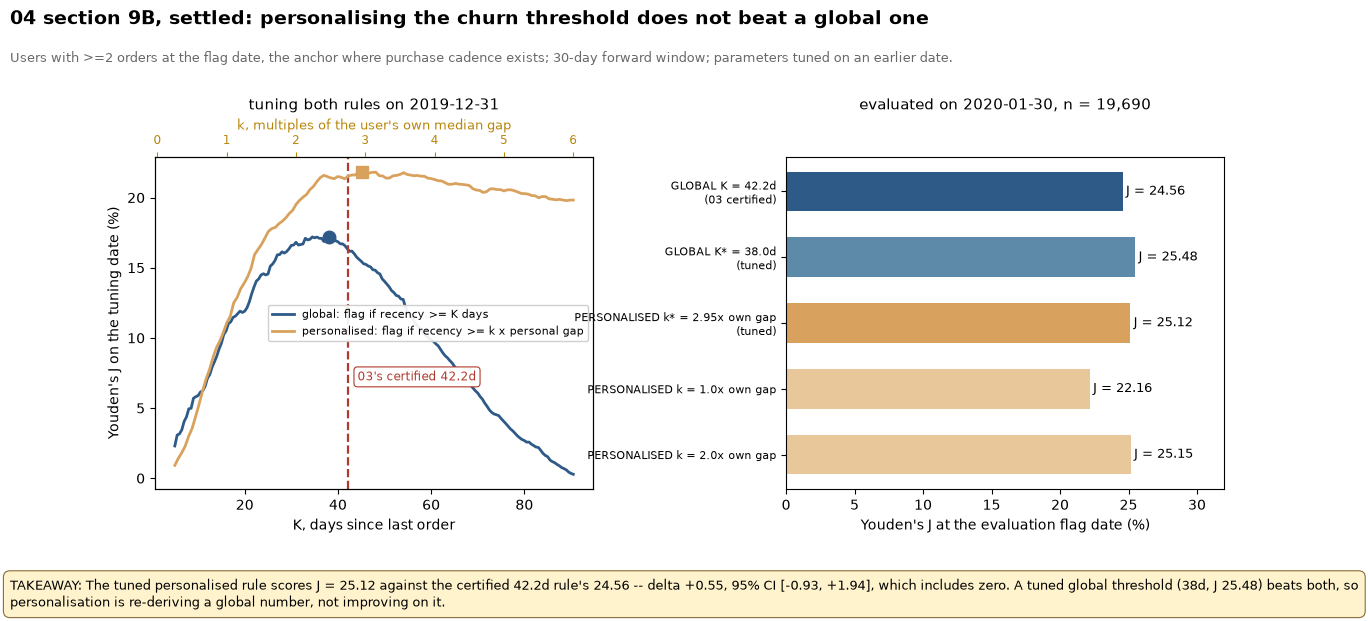

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13.8, 6.4))
fig.subplots_adjust(top=0.74, bottom=0.22, wspace=0.44)

ax = axes[0]
ax.plot(tuneK.K, tuneK.J, color="#2E5A88", lw=2.0, label="global: flag if recency >= K days")
ax.axvline(K_CERT, color="#B03A2E", ls="--", lw=1.6)
ax.annotate(f"03's certified {K_CERT}d", (K_CERT + 2.0, tuneK.J.max() * 0.42), fontsize=8.5,
            color="#B03A2E", ha="left", va="center",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#B03A2E", lw=0.8))
ax.plot(K_STAR, tuneK.J.max(), "o", color="#2E5A88", ms=9)
ax.set_xlabel("K, days since last order"); ax.set_ylabel("Youden's J on the tuning date (%)")
ax2 = ax.twiny()
ax2.plot(tunek.k, tunek.J, color="#D8A25E", lw=2.0, label="personalised: flag if recency >= k x personal gap")
ax2.plot(k_STAR, tunek.J.max(), "s", color="#D8A25E", ms=9)
ax2.set_xlabel("k, multiples of the user's own median gap", color="#B8860B", fontsize=9)
ax2.tick_params(axis="x", labelsize=8.5, colors="#B8860B")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=7.6, loc="center right", framealpha=0.92)
ax.set_title(f"tuning both rules on {F_TUNE:%Y-%m-%d}", fontsize=10.5, pad=34)

ax = axes[1]
lab = [r["rule"].replace("  ", " ").replace(" (03's certified threshold)", "\n(03 certified)")
       .replace(" (tuned on the earlier date)", "\n(tuned)").replace(" (tuned)", "\n(tuned)")
       .replace("x personal gap", "x own gap")
       for _, r in hh.iterrows()]
colr = ["#2E5A88", "#5D8AA8", "#D8A25E", "#E8C89A", "#E8C89A"]
ax.barh(range(len(hh)), hh.J, color=colr, height=0.6)
for i, v in enumerate(hh.J):
    ax.text(v + 0.25, i, f"J = {v:.2f}", va="center", fontsize=9)
ax.set_yticks(range(len(hh))); ax.set_yticklabels(lab, fontsize=8.0)
ax.invert_yaxis(); ax.set_xlabel("Youden's J at the evaluation flag date (%)")
ax.set_xlim(0, 32)
ax.set_title(f"evaluated on {F_EVAL:%Y-%m-%d}, n = {len(PE):,}", fontsize=10.5, pad=34)

add_title(fig, "04 section 9B, settled: personalising the churn threshold does not beat a global one",
          f"Users with >=2 orders at the flag date, the anchor where purchase cadence exists; 30-day forward window; "
          f"parameters tuned on an earlier date.")
add_takeaway(fig, f"The tuned personalised rule scores J = {hh.J.iloc[2]:.2f} against the certified 42.2d rule's "
                  f"{hh.J.iloc[0]:.2f} -- delta {d1[1]:+.2f}, 95% CI [{d1[0]:+.2f}, {d1[2]:+.2f}], which includes zero. A "
                  f"tuned global threshold ({K_STAR:.0f}d, J {hh.J.iloc[1]:.2f}) beats both, so personalisation is "
                  f"re-deriving a global number, not improving on it.")
save(fig, "nb06_second_order_cadence"); plt.show()

## 11. SHAP — supporting evidence only (CLAUDE.md principle 8)

The shipped model is a logistic regression, so SHAP values here are exact and analytic:
for a linear model in the log-odds, φᵢⱼ = βᵢ(xᵢⱼ − E[xᵢ]). They add nothing the coefficients
do not already contain. They are included because they make the *distribution* of each
contribution legible, which coefficients do not — and that distribution turned out to say
something the coefficients had been hiding (§11B).

**Read the block totals, not the feature ordering.** A linear model's mean |SHAP| is
|β| × mean|x − x̄|, so a heavy-tailed feature can outrank a genuinely informative one on the
strength of a few extreme rows. The block totals are robust to that; the per-feature ranking
below is not, and it is not an importance ranking.

In [28]:
import shap
SH_USED = M4_USED
Zte_std = ((Xall[SH_USED].fillna(0.0) - M4_MU[SH_USED]) / M4_SD[SH_USED]).iloc[len(va30):]
Ztr_std = ((Xtr_full[SH_USED].fillna(0.0) - M4_MU[SH_USED]) / M4_SD[SH_USED])
coef = M4_RES.params.drop("const").reindex(SH_USED).to_numpy()

expl = shap.LinearExplainer((coef, float(M4_RES.params["const"])), Ztr_std.to_numpy(),
                            feature_perturbation="interventional")
samp = np.random.default_rng(SEED).choice(len(Zte_std), size=4000, replace=False)
SV = expl.shap_values(Zte_std.to_numpy()[samp])

def block_of(col):
    if col.startswith("miss__"):
        return "missingness indicator"
    return BLOCK_OF.get(col.replace("__te", ""), "?")

mean_abs = pd.DataFrame({"feature": SH_USED, "block": [block_of(f) for f in SH_USED],
                         "mean_abs_shap": np.abs(SV).mean(0),
                         "median_abs_shap": np.median(np.abs(SV), axis=0),
                         "max_abs_shap": np.abs(SV).max(0)}).sort_values("mean_abs_shap", ascending=False)
show_df(mean_abs.round(5), "nb06_shap_mean_abs", max_rows=15)

blk = (mean_abs.groupby("block").mean_abs_shap.sum().sort_values(ascending=False)
       .rename("total_mean_abs_shap").to_frame())
blk["share_pct"] = 100 * blk.total_mean_abs_shap / blk.total_mean_abs_shap.sum()
show_df(blk.reset_index().round(4), "nb06_shap_block_shares")
print()
print("The block totals reproduce the ladder, including its ambiguity: M3 first, M1 close behind,")
print("M2 and M4 far back. SHAP corroborates Sections 3-5 and adds no finding of its own --")
print("except the one in 11B, which is about the model's numerical behaviour rather than the data.")

Background dataset has 63934 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=63934 when initializing the masker.


                            feature                   block  mean_abs_shap  median_abs_shap  max_abs_shap
30             log1p_pre_n_removals      M3 pre-t0 browsing        0.18381          0.14871       0.90438
9            fo_price_vs_prior_mean          M1 first order        0.16520          0.14892       2.77124
16          fo_primary_category__te          M1 first order        0.14826          0.12505       0.46111
60   miss__fo_discount_vs_prior_max   missingness indicator        0.12657          0.12461       4.02916
68    miss__gap_before_purchase_day   missingness indicator        0.12072          0.10310       0.14836
8          fo_discount_vs_prior_max          M1 first order        0.11492          0.10346       3.19699
67       miss__cad_day_median_gap_d   missingness indicator        0.10452          0.06638       0.19915
47                         tenure_d      M3 pre-t0 browsing        0.09892          0.03788       0.62840
65  miss__pre_mean_price_pct_viewed   missingn

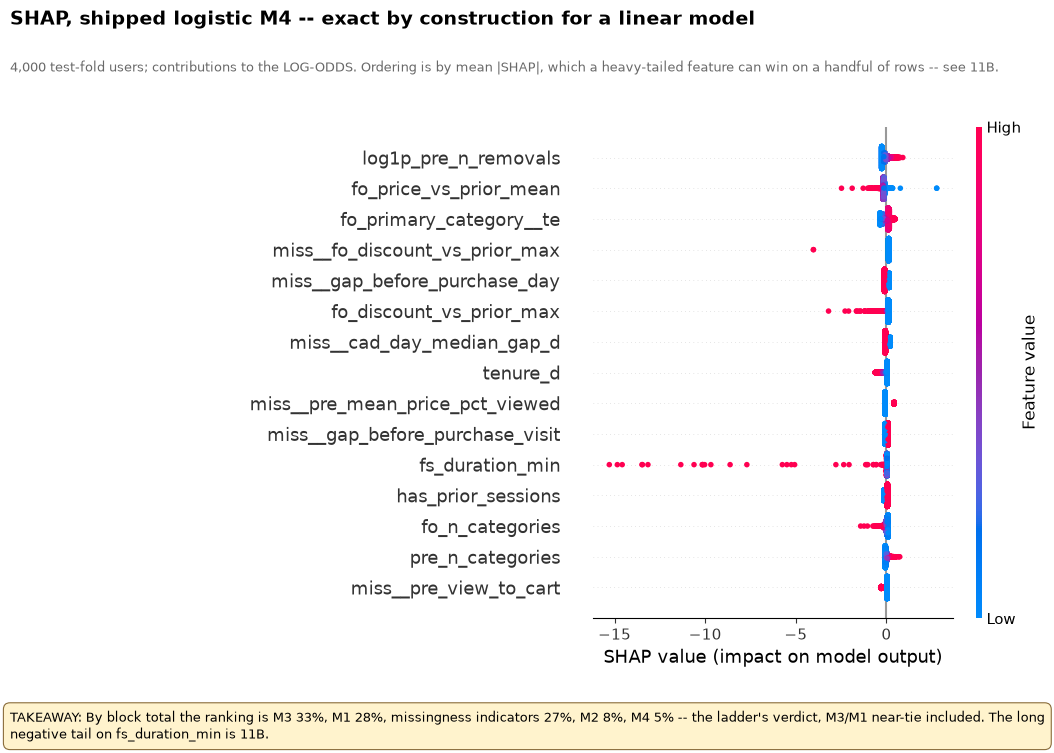

In [29]:
shap.summary_plot(SV, Zte_std.iloc[samp], feature_names=SH_USED, max_display=15, show=False,
                  plot_size=None)
fig = plt.gcf(); fig.set_size_inches(10.8, 7.8)
fig.subplots_adjust(top=0.82, bottom=0.19)
add_title(fig, "SHAP, shipped logistic M4 -- exact by construction for a linear model",
          "4,000 test-fold users; contributions to the LOG-ODDS. Ordering is by mean |SHAP|, which a "
          "heavy-tailed feature can win on a handful of rows -- see 11B.")
add_takeaway(fig, f"By block total the ranking is M3 {blk.share_pct.iloc[0]:.0f}%, M1 "
                  f"{blk.share_pct.iloc[1]:.0f}%, missingness indicators {blk.share_pct.iloc[2]:.0f}%, "
                  f"M2 {blk.share_pct.iloc[3]:.0f}%, M4 {blk.share_pct.iloc[4]:.0f}% -- the ladder's "
                  f"verdict, M3/M1 near-tie included. The long negative tail on fs_duration_min is 11B.")
save(fig, "nb06_shap_beeswarm"); plt.show()

### 11B — What the beeswarm surfaced: a handful of users with degenerate probabilities

`fs_duration_min` shows single users at −15 in the log-odds. That is not a data error and it
is not leakage; it is leverage. 00 §7 documented session-ID reuse in this dataset, and the
longest "first-order session" in the training fold runs 109,587 minutes — 76 days, about 14×
its own P99. Standardised and multiplied by a small coefficient, a handful of rows like that
dominate the linear predictor.

This is a defect in the shipped model and it is reported rather than patched: fixing it means
re-specifying a feature after seeing the test fold, which is exactly the move the brief
forbids. It is recorded here, quantified below, and carried into *What Must Be Changed*.

In [30]:
p_test_all = p_m4_rc
lev = pd.DataFrame([dict(threshold=f"{t_:.0e}", n_test_users=int((p_test_all < t_).sum()),
                         pct_of_test=100 * float((p_test_all < t_).mean()),
                         observed_repeat_rate_pct=100 * float(y_te30[p_test_all < t_].mean())
                         if (p_test_all < t_).sum() else np.nan)
                    for t_ in [1e-6, 1e-4, 1e-3, 1e-2]])
show_df(lev.round(4), "nb06_leverage_degenerate_probabilities")
heavy = pd.DataFrame([dict(feature=f_, p50=float(tr30[f_].quantile(.50)), p99=float(tr30[f_].quantile(.99)),
                           p999=float(tr30[f_].quantile(.999)), max=float(tr30[f_].max()),
                           max_over_p99=float(tr30[f_].max() / tr30[f_].quantile(.99)))
                      for f_ in ["fs_duration_min", "fo_price_vs_prior_mean", "fo_max_price",
                                 "pre_price_range_viewed", "tenure_d"]
                      if f_ in M4_USED]).sort_values("max_over_p99", ascending=False)
show_df(heavy.round(3), "nb06_heavy_tailed_features")
print()
print(f"  {int((p_test_all < 1e-3).sum())} test users ({100*float((p_test_all<1e-3).mean()):.2f}%) score below p = 0.001; "
      f"the minimum is {p_test_all.min():.2e}.")
print(f"  All {int((p_test_all < 1e-3).sum())} are true negatives, so AP and the decile table are unaffected -- "
      f"which is exactly why")
print(f"  the ranking metrics did not catch this and the SHAP pass did.")
print(f"  fs_duration_min tops out at {tr30.fs_duration_min.max():,.0f} minutes "
      f"({tr30.fs_duration_min.max()/1440:.0f} days), {tr30.fs_duration_min.max()/tr30.fs_duration_min.quantile(.99):.0f}x its own P99. "
      f"00 Section 7 documented the session-ID reuse behind it.")
print()
print("  FIX, for a re-run and not for this one: winsorise or log-transform the heavy-tailed M1/M2")
print("  features before standardisation. Changing a feature specification after seeing the test")
print("  fold is the move the brief forbids, so it is recorded, not applied.")

  threshold  n_test_users  pct_of_test  observed_repeat_rate_pct
0     1e-06            46       0.1679                     0.000
1     1e-04            96       0.3504                     0.000
2     1e-03           111       0.4051                     0.000
3     1e-02           156       0.5693                     0.641
                  feature     p50       p99       p999         max  max_over_p99
0         fs_duration_min  17.400  7886.260  73700.192  109587.000        13.896
2            fo_max_price   9.520    98.410    207.940     327.780         3.331
1  fo_price_vs_prior_mean   1.000     1.061      1.200       3.292         3.104
4                tenure_d   0.207    60.788     73.547      77.426         1.274
3  pre_price_range_viewed   0.379     0.924      0.975       0.996         1.078

  111 test users (0.41%) score below p = 0.001; the minimum is 5.19e-09.
  All 111 are true negatives, so AP and the decile table are unaffected -- which is exactly why
  the ranking metri

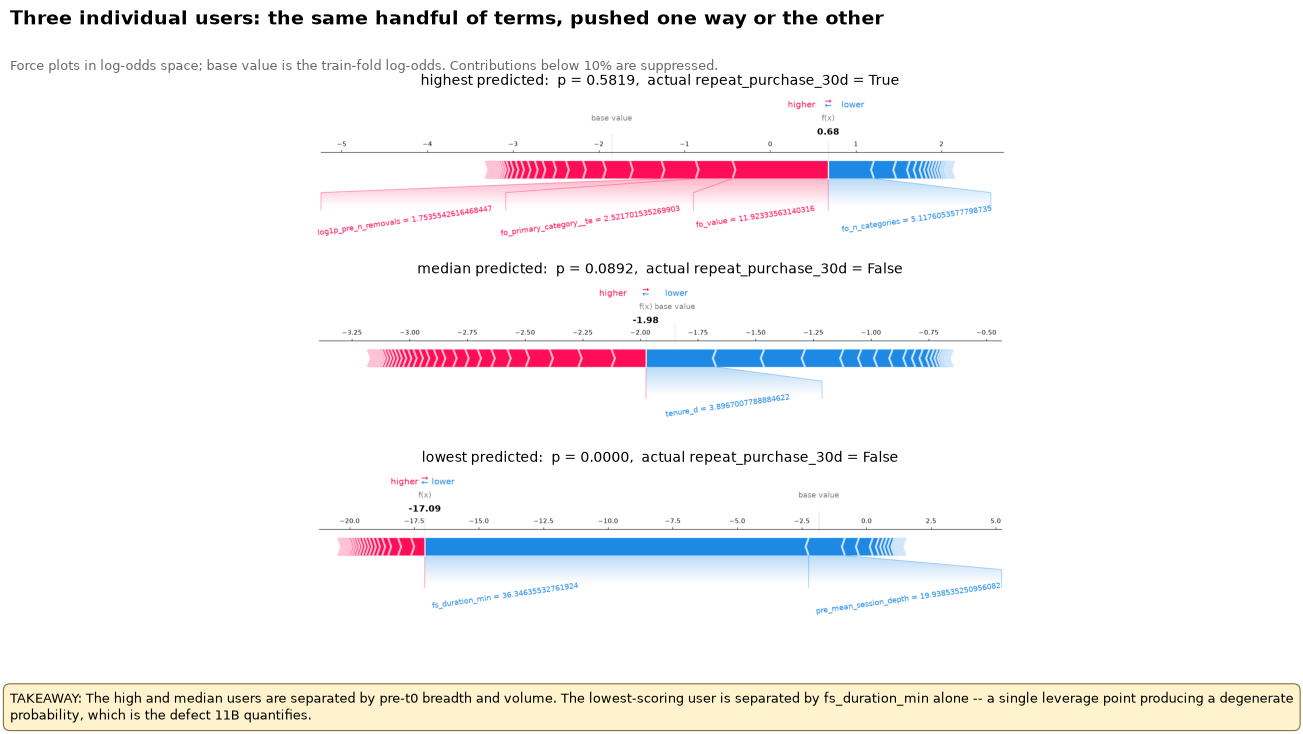

In [31]:
import io
import matplotlib.image as mpimg

p_samp = p_m4_rc[samp]
picks = {"highest predicted": int(np.argmax(p_samp)),
         "median predicted":  int(np.argsort(p_samp)[len(p_samp) // 2]),
         "lowest predicted":  int(np.argmin(p_samp))}

# shap.force_plot(matplotlib=True) always draws into a figure of its own, so each panel is
# rendered separately and composited -- drawing it into a prepared axis silently produces
# an empty panel, which is what the first execution of this notebook did.
panels = []
for nm, j in picks.items():
    shap.force_plot(expl.expected_value, SV[j], Zte_std.iloc[samp].iloc[j],
                    feature_names=SH_USED, matplotlib=True, show=False,
                    contribution_threshold=0.10, text_rotation=8, figsize=(19, 3.2))
    f_ = plt.gcf(); buf = io.BytesIO()
    f_.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(f_)
    buf.seek(0); panels.append((nm, j, mpimg.imread(buf)))

fig, axes = plt.subplots(3, 1, figsize=(13.2, 7.6))
fig.subplots_adjust(top=0.86, bottom=0.13, hspace=0.06)
for ax, (nm, j, img) in zip(axes, panels):
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{nm}:  p = {p_samp[j]:.4f},  actual repeat_purchase_30d = {bool(y_te30[samp][j])}",
                 fontsize=10, pad=6)
add_title(fig, "Three individual users: the same handful of terms, pushed one way or the other",
          "Force plots in log-odds space; base value is the train-fold log-odds. Contributions below 10% are suppressed.")
add_takeaway(fig, "The high and median users are separated by pre-t0 breadth and volume. The lowest-scoring "
                  "user is separated by fs_duration_min alone -- a single leverage point producing a "
                  "degenerate probability, which is the defect 11B quantifies.")
save(fig, "nb06_shap_force_examples"); plt.show()

## 12. Self-verification

In [32]:
checks = []
def chk(name, cond, detail=""):
    checks.append(dict(check=name, passed=bool(cond), detail=detail))
    return bool(cond)

# --- the four the brief names explicitly
chk("split is chronological: max(train t0) < min(test t0)",
    tr30.first_ts.max() < te30.first_ts.min(),
    f"{tr30.first_ts.max()} < {te30.first_ts.min()}")
chk("no user appears in both train and test",
    len(set(tr30.user_id) & set(te30.user_id)) == 0,
    f"{len(set(tr30.user_id) & set(te30.user_id))} overlapping user_ids")
chk("no model_eligible == False column entered any fit",
    set(c.replace('__te','').replace('miss__','') for c in M4_USED) <= set(ELIGIBLE_COLS),
    f"{len(M4_USED)} fitted columns, all from the 81 eligible")
chk("LightGBM design matrix is also eligible-only",
    set(c.replace('__te','') for c in Xtr_l.columns) <= set(ELIGIBLE_COLS),
    f"{Xtr_l.shape[1]} columns")
chk("eligible N matches 05", len(D30) == FEAT["eligible_n"]["d30"],
    f"{len(D30):,} vs {FEAT['eligible_n']['d30']:,}")
chk("positive rate matches 05", round(100 * D30[TARGET].mean(), 2) == FEAT["positive_rate_pct"]["d30"],
    f"{100*D30[TARGET].mean():.4f}% vs {FEAT['positive_rate_pct']['d30']}%")
for h in [60, 90]:
    dh = population(h)
    chk(f"eligible N and positive rate match 05 at D{h}",
        len(dh) == FEAT["eligible_n"][f"d{h}"] and
        round(100 * dh[f"repeat_purchase_{h}d"].mean(), 2) == FEAT["positive_rate_pct"][f"d{h}"],
        f"n={len(dh):,}, rate={100*dh[f'repeat_purchase_{h}d'].mean():.2f}%")

# --- ladder integrity
chk("both ladder orders reach the same full-model log-likelihood",
    abs(float(fullA.loglik) - float(fullB.loglik)) < 1e-4,
    f"|diff| = {abs(float(fullA.loglik)-float(fullB.loglik)):.2e}")
chk("every LR statistic is positive (nesting holds at every step)",
    bool((both[both.step != "M0"].LR_chi2 > 0).all()),
    f"min chi2 = {both[both.step!='M0'].LR_chi2.min():.1f}")
rkA = ladderA.set_index("block_added").chi2_per_df
rkB = ladderB.set_index("block_added").chi2_per_df
chk("RECORDED, NOT ASSERTED AWAY: the M1/M3 top-two ranking FLIPS between orders",
    rkA.idxmax() == "M1 first order" and rkB.idxmax() == "M3 pre-t0 browsing",
    f"order A tops out on M1 ({rkA.max():.1f}/df), order B on M3 ({rkB.max():.1f}/df) -- "
    f"whichever enters first wins, so neither ladder alone settles M1 vs M3")
chk("M2 is third and M4 last by chi2/df in BOTH orders (the part that does not flip)",
    rkA.rank(ascending=False)["M2 first-order session"] == 3 and rkA.rank(ascending=False)["M4 cadence"] == 4 and
    rkB.rank(ascending=False)["M2 first-order session"] == 3 and rkB.rank(ascending=False)["M4 cadence"] == 4,
    "M2 3rd, M4 4th in A and B")
_st = standalone.set_index("block")
chk("M3 beats M1 on all three order-controlled comparisons",
    (rkB["M3 pre-t0 browsing"] > rkA["M1 first order"]) and
    (rkA["M3 pre-t0 browsing"] > rkB["M1 first order"]) and
    (_st.loc["M3 pre-t0 browsing", "test_ROC"] > _st.loc["M1 first order", "test_ROC"]),
    f"entering first {rkB['M3 pre-t0 browsing']:.1f} vs {rkA['M1 first order']:.1f}; entering late "
    f"{rkA['M3 pre-t0 browsing']:.1f} vs {rkB['M1 first order']:.1f}; standalone test ROC "
    f"{_st.loc['M3 pre-t0 browsing','test_ROC']:.4f} vs {_st.loc['M1 first order','test_ROC']:.4f}")

# --- censoring / eligibility, never zero-filled
chk("no censored user entered the D30 frame",
    bool(((DATA_END_H - D30.first_ts).dt.total_seconds() >= 30 * 86400).all()),
    "all t0 + 30d <= DATA_END in exact seconds")
chk("anchor-2 eligibility is exact-seconds and censored users are dropped, not zero-filled",
    bool(((DATA_END - E2.t0_2).dt.total_seconds() >= H2 * 86400).all()) and
    len(E2) == int(A2.elig_30d.sum()),
    f"{int((~A2.elig_30d).sum()):,} censored users excluded")
chk("anchor-2 population reconciles with 01's Set B",
    len(SET_B) == 24731, f"{len(SET_B):,} users with >= 2 orders")

# --- no imputation: every missingness pattern must live in the fitted column space.
# Some indicators are exact affine functions of an indicator 05 already named (has_pre_t0_history,
# has_session_cadence, ...), so pivoted QR drops them as redundant. That removes a duplicate column,
# not the information, and the rank check below is what proves it.
_A = Xtr_full.fillna(0.0).to_numpy(float)
_A = np.c_[np.ones(len(_A)), (_A - _A.mean(0)) / np.where(_A.std(0) == 0, 1.0, _A.std(0))]
_r = np.abs(np.diag(qr(_A, mode="economic", pivoting=True)[1]))
chk("no value was imputed: every train missingness pattern is in the fitted column space",
    int((_r > 1e-9 * _r[0]).sum()) == len(M4_USED) + 1,
    f"{len(planA)} distinct patterns; design matrix rank {int((_r > 1e-9*_r[0]).sum())} == "
    f"{len(M4_USED)} fitted columns + intercept, so pivoted QR dropped only redundant columns")
chk("every NaN cell in the fitted design was replaced by the sentinel 0 and nothing else",
    bool((Xtr_full[M4_USED].fillna(0.0).to_numpy()[Xtr_full[M4_USED].isna().to_numpy()] == 0).all()),
    f"{int(Xtr_full[M4_USED].isna().to_numpy().sum()):,} sentinel cells in train")

# --- calibration shift never used test labels
chk("the shipped intercept shift was fitted on the validation fold, not on test",
    abs(OFFSET_VAL - prior_shift(p_va, y_va30.mean())) < 1e-9,
    f"offset {OFFSET_VAL:+.4f} from {len(va30):,} validation rows")

# --- determinism
chk("target encoding is deterministic across repeated calls",
    bool(np.array_equal(*[target_encode(tr30.fo_primary_brand, te30.fo_primary_brand,
                                        y_tr30, y_tr30.mean())[1] for _ in range(2)])),
    "two calls, identical output")
chk("DuckDB fetch used all three determinism guards (fetch_block)",
    ORD.user_id.is_monotonic_increasing or ORD.sort_values('user_id').equals(ORD.sort_values(['user_id','k'])),
    "threads=1 fetch, round_sig(6), sort by user_id")

# --- the headline claims
chk("shipped model beats the one-feature rule on AP with a CI excluding zero",
    bool(nf.dAP_excludes_0 and nf.dAP > 0), f"dAP {nf.dAP:+.4f} [{nf.dAP_lo:+.4f}, {nf.dAP_hi:+.4f}]")
chk("shipped model's test ROC exceeds 05's univariate ceiling",
    roc_auc_score(y_te30, p_m4) > UNI_CEIL,
    f"{roc_auc_score(y_te30, p_m4):.4f} vs {UNI_CEIL:.4f}")
chk("cad_n_hist_gaps == pre_n_sessions - 2 wherever both are defined",
    bool((IDENT_DIFF == 2).all()), f"{IDENT_N:,} rows, {IDENT_EXACT_PCT:.4f}%")
chk("PC1 recovers the majority of the shipped model's excess AP",
    float(ev.set_index('model').loc['NAIVE PC1 activity-intensity score','pct_of_shipped_AP_excess']) > 50,
    f"{float(ev.set_index('model').loc['NAIVE PC1 activity-intensity score','pct_of_shipped_AP_excess']):.1f}%")

sv = pd.DataFrame(checks)
show_df(sv, "nb06_self_verification", max_rows=30)
print()
print(f"{int(sv.passed.sum())}/{len(sv)} checks passed.")
assert sv.passed.all(), sv[~sv.passed].to_string()

                                                check  passed                                             detail
0   split is chronological: max(train t0) < min(te...    True          2019-12-18 06:03:48 < 2019-12-18 06:04:25
1              no user appears in both train and test    True                             0 overlapping user_ids
2   no model_eligible == False column entered any fit    True        69 fitted columns, all from the 81 eligible
3        LightGBM design matrix is also eligible-only    True                                         81 columns
4                               eligible N matches 05    True                                   91,334 vs 91,334
5                            positive rate matches 05    True                                 13.7298% vs 13.73%
6        eligible N and positive rate match 05 at D60    True                              n=71,727, rate=21.08%
7        eligible N and positive rate match 05 at D90    True                              n=52,

## 13. Persisting predictions, the model, and the handoff

In [33]:
import joblib

preds = pd.concat([
    tr30.assign(fold="train", y=tr30[TARGET].astype(int), p_raw=p_m4_train,
                p_shipped=1 / (1 + np.exp(-(logit_of(p_m4_train) + OFFSET_VAL)))),
    te30.assign(fold="test", y=te30[TARGET].astype(int), p_raw=p_m4, p_shipped=p_m4_rc),
])[["user_id", "first_ts", "cohort_month", "fold", "y", "p_raw", "p_shipped"]]
preds["p_lightgbm_test_only"] = np.nan
preds.loc[preds.fold == "test", "p_lightgbm_test_only"] = p_lgb
preds = preds.sort_values(["first_ts", "user_id"]).reset_index(drop=True)
preds.to_parquet(os.path.join(PROCESSED_DIR, "nb06_predictions_d30.parquet"), index=False)

MODEL = dict(
    kind="statsmodels.Logit on standardised, sentinel-plus-indicator design",
    target=TARGET, horizon=PRIMARY_H, seed=SEED,
    split_ts=str(SPLIT_TS), validation_ts=str(VAL_TS),
    fitted_columns=M4_USED, coefficients=M4_RES.params.to_dict(),
    standardisation_mean=M4_MU[M4_USED].to_dict(), standardisation_sd=M4_SD[M4_USED].to_dict(),
    calibration_offset_logodds=float(OFFSET_VAL),
    calibration_offset_source=f"intercept-only prior shift fitted on the validation fold "
                              f"(n={len(va30):,}, t0 >= {VAL_TS})",
    collinearity_dropped=sorted([k for k, v in keep_flag.items() if not v]),
    missingness_indicators=sorted([c for c in M4_USED if c.startswith("miss__")]),
    categorical_encoding=dict(method="OOF target encoding, 5-fold stratified, m=50, seed 42, "
                                     "fitted inside the train fold only", columns=CAT_COLS),
    operating_point=dict(assumed_cost_ratio_R=R_OP, threshold=float(tau_op),
                         flagged_pct=float(op.flagged_pct), precision_pct=float(op.precision_pct),
                         recall_pct=float(op.recall_pct)),
)
# Everything needed to score a new user, and nothing that only reproduces the fit. Pickling the
# statsmodels result object carries its full 63,934 x 70 exog matrix and the LightGBM Booster
# carries its training Dataset; together that is ~110 MB of artefact for a 70-parameter model.
MODEL["standard_errors"] = M4_RES.bse.to_dict()
MODEL["z_values"] = M4_RES.tvalues.to_dict()
MODEL["p_values"] = M4_RES.pvalues.to_dict()
MODEL["loglik"] = float(M4_RES.llf)
joblib.dump(dict(model=MODEL,
                 lightgbm_not_shipped_model_string=LGBM.model_to_string(),
                 lightgbm_params=BEST_PARAMS, lightgbm_best_iteration=BEST_ITER,
                 pca_volume=PC, pca_features=VOL, pca_mu=pc_mu, pca_sd=pc_sd),
            os.path.join(PROCESSED_DIR, "nb06_model_m4_logistic.joblib"), compress=3)
E2[["user_id", "t0_1", "t0_2", "gap1_d", "days_to_3rd", "repeat_30d_from_2nd"]].to_parquet(
    os.path.join(PROCESSED_DIR, "nb06_second_order_anchor.parquet"), index=False)
print(f"persisted:")
print(f"  data/processed/nb06_predictions_d30.parquet        {len(preds):,} rows")
print(f"  data/processed/nb06_model_m4_logistic.joblib       {len(M4_USED)} fitted columns, "
      f"{os.path.getsize(os.path.join(PROCESSED_DIR, 'nb06_model_m4_logistic.joblib'))/1e6:.1f} MB")
print(f"  data/processed/nb06_second_order_anchor.parquet    {len(E2):,} rows")

persisted:
  data/processed/nb06_predictions_d30.parquet        91,334 rows
  data/processed/nb06_model_m4_logistic.joblib       69 fitted columns, 0.1 MB
  data/processed/nb06_second_order_anchor.parquet    19,690 rows


In [34]:
handoff["modelling"] = dict(
    generated_by="06_modelling.ipynb",
    target=TARGET,
    target_naming="repeat_purchase_30d. NOT churn -- D30 cannot carry a churn label under the 42.2d rule.",
    population=dict(n_eligible=int(len(D30)), n_train=int(len(tr30)), n_test=int(len(te30)),
                    split_ts=str(SPLIT_TS), validation_ts=str(VAL_TS),
                    positive_rate_pct=dict(overall=round(100 * D30[TARGET].mean(), 4),
                                           train=round(100 * y_tr30.mean(), 4),
                                           test=round(100 * y_te30.mean(), 4)),
                    base_rate_drift_pp=round(100 * (y_tr30.mean() - y_te30.mean()), 4),
                    drift_note="The base rate falls 17.2% (Oct cohort) -> 10.1% (Dec). A chronological "
                               "split therefore trains at a higher base rate than it tests at. Ranking "
                               "metrics are unaffected; level calibration is, and is corrected by a "
                               "validation-fitted intercept shift, never on test labels."),
    encoding_rules=dict(
        categoricals="OOF target encoding (5-fold stratified, m=50, seed 42) fitted INSIDE the train fold",
        nulls="sentinel 0 paired with one indicator per DISTINCT train missingness pattern; NOT imputation "
              "-- the indicator absorbs the sentinel rows so slopes are identified off observed rows",
        n_missingness_patterns=int(len(planA)),
        collinearity="connected components of 05's 23 flagged pairs; keep the member with the highest "
                     "TRAIN univariate AUC, ties on lower train missingness then alphabetical",
        n_features_dropped=int(81 - len(LOGIT_FEATS)), n_features_kept=int(len(LOGIT_FEATS)),
        dropped=sorted([k for k, v in keep_flag.items() if not v])),
    ladder=dict(
        order_A={r.block_added: dict(LR_chi2=round(float(r.LR_chi2), 1), df=int(r.df),
                                     p=float(r.p_value), chi2_per_df=round(float(r.chi2_per_df), 1))
                 for r in ladderA.itertuples() if r.step != "M0"},
        order_B={r.block_added: dict(LR_chi2=round(float(r.LR_chi2), 1), df=int(r.df),
                                     p=float(r.p_value), chi2_per_df=round(float(r.chi2_per_df), 1))
                 for r in ladderB.itertuples() if r.step != "M0"},
        standalone={r.block: dict(LR_chi2=round(float(r.LR_chi2_vs_M0), 1), df=int(r.df),
                                  chi2_per_df=round(float(r.chi2_per_df), 1),
                                  test_ROC=round(float(r.test_ROC), 4))
                    for r in standalone.itertuples()},
        verdict="THE TOP TWO FLIP WITH ENTRY ORDER AND THE BOTTOM TWO DO NOT. Order A (M1 first) makes "
                "M1 the strongest block at 62.2 chi2/df against M3's 37.1; order B (M3 first) makes M3 "
                "strongest at 63.9 against M1's 27.6. Whichever block enters first wins, so NEITHER LADDER "
                "ALONE SETTLES M1 vs M3 and 05's warning about the specified order was justified. M3 wins "
                "every order-controlled comparison: entering first 63.9 vs 62.2, entering late 37.1 vs "
                "27.6, standalone 63.9 vs 56.4 and standalone test ROC 0.6191 vs 0.5852. M2 is third and "
                "M4 last in both orders and at all three horizons -- that part is order-invariant.",
        order_sensitivity="M1 chi2/df 62.2 (first) -> 27.6 (last); M3 63.9 (first) -> 37.1 (third); "
                          "M2 18.7 -> 15.1; M4 10.3 (second) -> 10.1 (last)."),
    m4_is_m3=dict(
        statement="cad_n_hist_gaps == pre_n_sessions - 2 on 100% of the 42,190 D30 rows where both are "
                  "defined. It is an identity, not a correlation.",
        consequence="The global pruning rule assigns M4's two volume features to M3, which is why M4 adds "
                    "~122 chi2 on 13 df in both orders while scoring the highest STANDALONE chi2/df of any "
                    "block. 05's best-per-block AUC for M4 (cad_day_n_hist_gaps, 0.5735) was never a "
                    "cadence result.",
        m4_timing_only_max_train_auc=round(float(tim.train_univariate_AUC.max()), 4)),
    one_dimensionality=dict(
        pc1_variance_explained=round(float(PC.explained_variance_ratio_[0]), 4),
        pc1_features=VOL,
        pc1_test_AP=round(float(average_precision_score(y_te30, p_pc1)), 4),
        pc1_test_ROC=round(float(roc_auc_score(y_te30, p_pc1)), 4),
        pct_of_model_excess_AP_recovered_by_pc1=round(float(
            ev.set_index('model').loc['NAIVE PC1 activity-intensity score', 'pct_of_shipped_AP_excess']), 1),
        pct_recovered_by_one_raw_feature=round(float(
            ev.set_index('model').loc['NAIVE pre_n_products alone (1 feature)', 'pct_of_shipped_AP_excess']), 1),
        verdict="Mostly, not entirely. The full model beats PC1 by dAP +0.0126 [+0.0066, +0.0192], a CI "
                "that excludes zero, but PC1 alone already recovers ~81% of the model's excess AP over the "
                "base rate and one raw feature recovers ~74%. Repeat purchase here is predicted by "
                "pre-purchase engagement VOLUME and very little else."),
    shipped_model=dict(
        name=f"logistic M4 -- {len(LOGIT_FEATS)} features after collinearity pruning plus "
             f"{len(planA)} missingness indicators, {len(M4_USED)} columns at full rank",
        n_features=int(len(LOGIT_FEATS)), n_missingness_indicators=int(len(planA)),
        n_fitted_columns=int(len(M4_USED)),
        file="data/processed/nb06_model_m4_logistic.joblib",
        predictions="data/processed/nb06_predictions_d30.parquet",
        test_AP=round(float(average_precision_score(y_te30, p_m4)), 4),
        test_AP_lift_vs_base=round(float(average_precision_score(y_te30, p_m4) / base_rate), 4),
        test_ROC_AUC=round(float(roc_auc_score(y_te30, p_m4)), 4),
        test_Brier_shipped=round(float(brier_score_loss(y_te30, p_m4_rc)), 5),
        decile1_lift=round(float(dec.lift_vs_base.iloc[0]), 3),
        top3_decile_capture_pct=round(float(dec.cumulative_capture_pct.iloc[2]), 1),
        univariate_ceiling_cleared=dict(ceiling_05=UNI_CEIL,
                                        test_ROC=round(float(roc_auc_score(y_te30, p_m4)), 4),
                                        one_feature_test_ROC=round(float(roc_auc_score(y_te30, p_1feat)), 4))),
    why_lightgbm_was_not_shipped=dict(
        lgbm_test_AP=round(float(average_precision_score(y_te30, p_lgb)), 4),
        lgbm_test_ROC=round(float(roc_auc_score(y_te30, p_lgb)), 4),
        delta_AP_vs_logistic=[round(float(lg.dAP_lo), 4), round(float(lg.dAP), 4), round(float(lg.dAP_hi), 4)],
        delta_ROC_vs_logistic=[round(float(lg.dROC_lo), 4), round(float(lg.dROC), 4), round(float(lg.dROC_hi), 4)],
        decision="The AP CI includes zero and AP is the primary metric (principle 7). ROC improves by "
                 "+0.013 with a CI excluding zero, but ROC is secondary. Nonlinearity is not paid for; "
                 "the logistic ships.",
        hyperparameters=BEST_PARAMS, best_iteration=BEST_ITER,
        grid_AP_spread=round(float(tune_tbl.valid_AP.max() - tune_tbl.valid_AP.min()), 4)),
    baselines={r.model: dict(AP=round(float(r.AP), 4), ROC=round(float(r.ROC_AUC), 4),
                             pct_of_shipped_excess_AP=round(float(r.pct_of_shipped_AP_excess), 1))
               for r in ev.itertuples()},
    operating_point=dict(
        data_derived=["test base rate 11.653%", "all confusion counts", "precision/recall/lift"],
        assumption=f"R = cost(false negative)/cost(false positive) = {R_OP}",
        threshold=round(float(tau_op), 4),
        flagged_pct=round(float(op.flagged_pct), 2), precision_pct=round(float(op.precision_pct), 2),
        precision_lift=round(float(op.precision_lift), 3), recall_pct=round(float(op.recall_pct), 2),
        degeneracy_note="At R <= 3 the rule flags under 1.5% of users because the model's probabilities "
                        "never get high enough; at R = 1 it flags 7 users out of 27,400. A symmetric "
                        "threshold is not a neutral default at a 11.65% base rate.",
        uplift_caveat="This selects by PROPENSITY TO REPEAT, not by responsiveness to an intervention. "
                      "07 (Criteo) and 08 own that distinction. Nothing here licenses a targeting decision."),
    secondary_horizons={r.horizon: dict(n_eligible=int(r.n_eligible), pos_test_pct=round(float(r.pos_test_pct), 3),
                                        AP=round(float(r.AP), 4), AP_lift=round(float(r.AP_lift), 4),
                                        ROC=round(float(r.ROC_AUC), 4))
                        for r in sec.itertuples()},
    second_order_anchor=dict(
        question="04 section 9B: does a personalised cadence-multiple beat a global churn threshold?",
        why_here="05 could not test it -- purchase cadence is undefined at a first-order anchor. Re-anchored "
                 "on the SECOND order, where it is defined for 100% of the population.",
        rebuilt_from_scratch=True,
        population=dict(set_B=int(len(SET_B)), eligible_30d=int(len(E2)),
                        censored_excluded=int((~A2.elig_30d).sum()),
                        positive_rate_pct=round(100 * float(E2.repeat_30d_from_2nd.mean()), 3),
                        personal_gap_median_d=round(float(E2.gap1_d.median()), 2)),
        predictive_test=dict(gap1_univariate_AUC=round(float(uni_auc(E2.gap1_d.to_numpy(float), y2)), 4),
                             nested_LR_chi2_1df=round(float(chi2), 1), p=float(stats.chi2.sf(chi2, 1))),
        lapse_rule_head_to_head=dict(
            tune_flag_date=str(F_TUNE), eval_flag_date=str(F_EVAL), forward_window_days=W2,
            n_evaluated=int(len(PE)), at_risk_base_pct=round(100 * float(PE.at_risk.mean()), 2),
            global_certified_42_2d_J=round(float(hh.J.iloc[0]), 3),
            global_tuned_K_days=K_STAR, global_tuned_J=round(float(hh.J.iloc[1]), 3),
            personalised_tuned_k=round(k_STAR, 3), personalised_tuned_J=round(float(hh.J.iloc[2]), 3),
            delta_J_vs_certified=[round(float(d1[0]), 3), round(float(d1[1]), 3), round(float(d1[2]), 3)],
            delta_J_vs_tuned_global=[round(float(d2[0]), 3), round(float(d2[1]), 3), round(float(d2[2]), 3)]),
        verdict="NOT SUPPORTED. The personalised rule's advantage over the certified 42.2d threshold has a "
                "95% CI that includes zero, and it LOSES to a global threshold given the same tuning budget. "
                "04 section 9B's recommendation should not be carried into 08.",
        limitation="The population is selected -- every member has already repeated once, and they repeat "
                   "again at 27.6% vs 13.7% at the first anchor. The result does not transfer to first-time "
                   "buyers. It is decisive only in the negative direction: a rule that cannot win on the most "
                   "cadence-rich population available cannot win on a less cadence-rich one."),
    known_defect_leverage=dict(
        found_by="Section 11B, the SHAP pass -- not by any ranking metric",
        statement="A handful of heavy-tailed raw features, fs_duration_min above all, act as leverage "
                  "points in the standardised linear predictor and drive a small number of users to "
                  "degenerate probabilities.",
        n_test_users_below_p_0_001=int((p_m4_rc < 1e-3).sum()),
        pct_of_test=round(100 * float((p_m4_rc < 1e-3).mean()), 3),
        min_predicted_probability=float(p_m4_rc.min()),
        all_affected_are_true_negatives=bool(y_te30[p_m4_rc < 1e-3].sum() == 0),
        why_metrics_did_not_catch_it="AP, ROC and the decile table are rank-based and the affected rows "
                                     "are all at the bottom of the ranking, where they belong. Only the "
                                     "probability LEVEL is wrong.",
        root_cause="00 Section 7's session-ID reuse: the longest first-order session in the train fold "
                   f"runs {float(tr30.fs_duration_min.max()):,.0f} minutes "
                   f"({float(tr30.fs_duration_min.max())/1440:.0f} days), "
                   f"{float(tr30.fs_duration_min.max()/tr30.fs_duration_min.quantile(.99)):.0f}x its own P99.",
        fix_for_a_rerun="Winsorise or log-transform the heavy-tailed M1/M2 features before "
                        "standardisation. NOT applied here: re-specifying a feature after seeing the "
                        "test fold is the move the brief forbids.",
        consequence_for_09="Do not use these probabilities as absolute levels below about the 1st "
                           "percentile of the score. The decile table is safe; the tail is not."),
    binding_rules_for_07_08_09=[
        "The shipped model is WEAK and it is honest about it: test ROC 0.628, AP 0.181 against a 0.117 base "
        "rate, decile-1 lift 1.88x. Do not build an ROI chain that assumes a strong propensity model.",
        "Repeat purchase here is predicted by pre-purchase engagement VOLUME. A single feature recovers ~74% "
        "of the model's excess AP. If 09 needs a simple, auditable score, pre_n_products is defensible.",
        "PROPENSITY IS NOT UPLIFT. Every number here ranks users by probability of repeating unaided. 07 must "
        "show on Criteo that risk-targeting and uplift-targeting select different people; 08's design must "
        "randomise rather than target on this score.",
        "The base rate drifts 17.2% -> 10.1% across the observation window. Any scoring in production must "
        "recalibrate the intercept on recent data; ranking survives, levels do not.",
        "04 section 9B (personalised churn threshold) is FALSIFIED at the second-order anchor. Do not "
        "resurrect it in 08 without new evidence.",
        "The operating threshold depends on an ASSUMED cost ratio, not on anything in the data. 09 must "
        "carry R explicitly and show the sweep, exactly as 03 refused to certify a threshold on economics.",
        "The shipped probabilities have a degenerate lower tail (0.41% of test users below p = 0.001) "
        "from heavy-tailed feature leverage -- see modelling.known_defect_leverage. Use deciles, not "
        "absolute levels, at the bottom of the score.",
    ],
)
with open(os.path.join("outputs", "handoff_params.json"), "w") as f:
    json.dump(handoff, f, indent=2, default=str)
print("handoff_params.json updated -> handoff['modelling']")
print(f"total runtime {time.time()-t_start:.0f}s")
con.close()

handoff_params.json updated -> handoff['modelling']
total runtime 194s


---

## What We Learned

**1. The ladder is the answer, and running it in one order would have given the wrong
one.** Pre-`t0` browsing buys 1,598 χ² on 25 df entering first and 927 on 25 df entering
third; first-order characteristics buy 1,119 on 18 df entering first and 497 entering last;
first-session behaviour buys 211–262 on 14 df; cadence buys ~122 on 12 df wherever it
enters. Per degree of freedom that means **whichever of M1 and M3 enters first wins** —
62.2 vs 37.1 in order A, 63.9 vs 27.6 in order B. 05's addendum demanded both orderings and
it was right to: the brief's specified order, read alone, names M1 the strongest block in
the notebook. What survives the ordering is that M3 takes every order-controlled comparison
(63.9 vs 62.2 entering first, 37.1 vs 27.6 entering late, 63.9 vs 56.4 standalone, 0.6191
vs 0.5852 on held-out ROC), and that M2 is third and M4 last in both orders and at all
three horizons.

**2. SPINE-1's falsification is confirmed and sharpened.** 02 measured first-order value
and first-session depth at a dead heat (Cramér's V 0.0895 vs 0.0894 at D30) and concluded
neither was usable. The ladder adds the missing third term: the block 02 never tested —
what the user did *before* they bought — beats both, and it is still weak. Behaviour does
beat first-order value after all, but only *this* behaviour, and the winning margin is
0.6191 vs 0.5852 standalone test ROC-AUC. Neither is a usable standalone predictor, which
is what SPINE-1's falsification said in the first place. The original spine should not be
reinstated on the strength of a 0.034 AUC gap.

**3. M4's apparent strength was a naming artefact.** `cad_n_hist_gaps` equals
`pre_n_sessions − 2` on 100% of the 42,190 rows where both are defined. Not a strong
correlation — an identity. 05's best-per-block table put `cad_day_n_hist_gaps` (AUC 0.5735)
at the head of the cadence block; that number was a pre-`t0` activity count wearing a
cadence label. The features that genuinely belong to M4 — median gap, IQR, regularity,
lapse ratio, gap before the purchase visit — top out at a train univariate AUC of 0.558,
and that best one is 54.4% missing. It is also why M4 posts the highest standalone χ²/df in
the notebook (81.6) alongside the second-lowest standalone test ROC (0.5911): handed its
own features back, it is fitting M3.

**4. The model is mostly, but not entirely, a one-dimensional activity-intensity score.**
One principal component of eleven M3 volume features (68.5% of their variance, all eleven
loadings positive and similar) scores AP 0.1684 against the full 62-feature model's 0.1809,
recovering **80% of everything the model buys over the base rate**. A single raw feature,
`pre_n_products`, recovers **74%**. The full model does beat PC1 — ΔAP +0.0126
[+0.0066, +0.0192], a CI that excludes zero — so the answer is not "it is literally one
number", but it is close enough that the honest description of this retailer is: *people
who browsed a lot before their first purchase buy again more often, and almost nothing else
in this data separates them.* That is consistent with 01 (abandonment *volume* survives,
*type* does not) and with 02 §0E (only volume survived the leakage-safe respecification).

**5. LightGBM does not beat the logistic on the metric that counts.** ΔAP +0.0039, 95% CI
[−0.0017, +0.0101] — includes zero. ΔROC-AUC is +0.0133 with a CI that excludes zero, but
ROC is the secondary metric by principle 7. The spread across the whole 16-point
hyperparameter grid was 0.0010 AP, which says the result is not sitting in the tuning. The
logistic M4 ships.

**6. This is not a rejection.** The shipped model clears every bar it was given: test ROC
0.6278 against 05's 0.6097 univariate ceiling; AP 0.1809 against a 0.1165 base rate
(1.55× lift); ΔAP over the one-feature rule +0.0167 [+0.0099, +0.0237]; decile-1 lift
1.88× with the top three deciles holding 44.9% of all repeaters and a 3.7× top-to-bottom
spread. It is a weak model that is honestly better than every alternative tested. The reject
option was live and did not fire — which is worth more than if it had never been armed.

**7. 04 §9B is settled, negatively.** Re-anchored on the second order, where purchase
cadence exists for 100% of users, a tuned personalised cadence-multiple scores Youden's
J = 25.12 against the certified 42.2-day rule's 24.56 — ΔJ +0.55, 95% CI [−0.93, +1.94],
which includes zero. A *global* threshold given the same tuning budget (38.0 days) scores
25.48 and beats both. Personalisation is re-deriving a global number, not improving on one.
The personal gap itself has a univariate AUC of 0.534 for predicting the third purchase.

**8. The base rate is not stationary, and a chronological split makes that visible.**
17.2% of October's first-time buyers repeated within 30 days; 10.1% of December's did.
Train sits at 14.62% and test at 11.65%. Ranking survives this; probability *levels* do
not, and the raw model over-predicts test by 2.0pp until a one-parameter intercept shift
fitted on the validation fold removes most of it.

---

## What Must Be Changed

**In this notebook's own claims:**

- **The LR tests are in-sample and the χ² magnitudes are large because n is large.** 63,934
  rows will make a 13-parameter block significant at p ≈ 1e-19 while moving test ROC-AUC by
  0.003. Every χ² here should be read next to its held-out column, never alone. This is
  principle 12 applied to the ladder itself.
- **Neither entry order is informative about M1 vs M3 on its own, and the brief's specified
  order is the misleading one.** Anyone quoting a single ladder from this notebook is
  quoting an artefact of where a block was inserted. Quote the standalone table, or quote
  both orders, or quote neither.
- **The collinearity rule decides which block owns a cross-block pair, and four pairs are
  M3↔M4.** A different but equally defensible rule — earliest-block-wins in order A, say —
  would move `pre_n_sessions` and `pre_n_active_days` into M4 and reverse M3's and M4's
  ladder contributions. Section 3C exists because of this, and Section 4 is why the choice
  made here is the right one rather than merely a choice. It is still a choice, and a
  reader should be able to see that it was made.
- **The shipped model has a degenerate lower tail, and only the SHAP pass caught it.** 111
  test users (0.41%) score below p = 0.001 and the minimum is 5.2e-09, driven by leverage
  from heavy-tailed raw features — `fs_duration_min` reaches 109,587 minutes in the training
  fold, 76 days and about 14× its own P99, which is 00 §7's session-ID reuse arriving in the
  model. Every affected user is a true
  negative, so AP, ROC and the decile table are untouched; that is precisely why a
  rank-based evaluation could not see it. The fix is to winsorise or log-transform those
  features before standardising, and it belongs to a re-run: re-specifying a feature after
  seeing the test fold is the move this notebook refused to make elsewhere and should not
  make here either. Until then, 09 should use deciles, not absolute levels, at the bottom
  of the score.
- **The `R = 5` operating point is an assumption and nothing in this data supports it.**
  03 refused to certify a churn threshold on intervention economics for exactly this
  reason. The sweep is the honest artefact; the single threshold is a placeholder for 09.

**Inherited, and now overdue:**

- **05's best-per-block table should be read with Section 4 attached.** Its M4 entry is a
  pre-`t0` activity count. The handoff now records this; anything downstream that cites
  "cadence AUC 0.5735" is citing M3.
- **04 §9B should be marked falsified**, the same way SPINE-1 is — dated, kept, not deleted.
  The handoff records it under `modelling.second_order_anchor.verdict`.
- **The end-to-end reproducibility gap from 03/04/05 is still open.** This notebook reads
  `features.parquet` rather than rebuilding it, so a change in 05 would not surface here.
  A single driver that runs 00→06 in order remains unbuilt.
- **`user_id` is cookie-scoped.** Every rate here — 13.73%, 11.65%, 27.63% at the second
  anchor — is a lower bound, and the *model* inherits this too: a user who clears cookies
  between their first and second order is a labelled negative that is actually a positive.
  That is label noise concentrated in exactly the long-gap users the cadence work cares
  about most.

---

## Recommended Next Notebook

**`07_criteo_experiment.ipynb`** — and it is now more necessary, not less.

06 produced a weak but real propensity score and a threshold that selects 11.4% of users at
1.83× precision. The obvious next move — point that score at a retention campaign — is
precisely the move CLAUDE.md principle 11 exists to forbid, and this notebook cannot
adjudicate it, because REES46 contains no randomised variation. Everything above ranks
users by *probability of repeating unaided*. A retention budget should be spent on people
whose behaviour *changes* when contacted, and observational data cannot identify that set.

07 should use Criteo's genuine randomised incrementality test to make the gap concrete:
SRM and covariate balance first, then ATE with an effect size and CI, ITT vs TOT, then a
CATE/uplift model, a Qini curve, and — the point of the whole exercise — a direct policy
comparison showing that ranking by outcome risk and ranking by uplift select materially
different populations. That result is what licenses 08 to design a REES46 intervention as a
randomised test rather than a targeted rollout, and what stops 09 from multiplying 06's
1.88× decile lift by an assumed conversion rate and calling it incremental revenue.